# Output integrity and physical consistency (regional run): `tas`, `tasmax`, `tasmin`, `dtr`, `pr`, `rsds`, `hurs`

Same three QA/QC parts as the production
[`output-integrity-checks.ipynb`](output-integrity-checks.ipynb) notebook -- output integrity
([#450](https://github.com/carbonplan/srm-downscaling/issues/450)), temperature ordering
`tasmin ≤ tas ≤ tasmax` ([#448](https://github.com/carbonplan/srm-downscaling/issues/448)), and
precipitation physical constraints
([#459](https://github.com/carbonplan/srm-downscaling/issues/459)) -- run instead against the
*regional (wide)* run: a spatial subset (lat -38 to -19, lon 13 to 36, southern Africa with the
neighbouring Atlantic and Indian Ocean) that carries every GCM (`CESM2-WACCM`, `MIROC-ES2H`,
`UKESM`), scenario, variable, and ensemble member, each in its own icechunk store on branch
`full-regional-run-issue-534`. `CESM2-WACCM` alone also carries `g6_1p5k_end`, the termination-shock
run (member `002`, 2085-2100). This is a temporary check against a scratch-bucket run, not a
production artifact.

Part 1 additionally carries four checks that production's notebook doesn't have, all of them
answering questions this run raised: are the leaves distinct from one another (Check 6), is the
expected set of leaves actually present (Check 7), is each time axis complete (Check 8), and is
every leaf on the grid it should be (Check 9). Check 1b reworks the NaN check so it means something
on a spatial subset. None of them read the stores again -- they reuse the single per-leaf pass that
Checks 1-5 already make, or run off coordinates alone.

In [1]:
import functools
import itertools
import operator
import os
from collections import defaultdict

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import coiled
import dask
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely
import xarray as xr
import zarr
from dask_array.xarray import register

from srm.config import ClusterConfig
from srm.qaqc import VAR_SPATIAL_RANGES
from srm.validation import _open_output_datatree, resolve_member_time_bounds

os.environ["FRISKY_SUMMARY"] = "off"
from frisky import hijack

# Activate frisky's query-optimized dask array backend for xarray before opening any store,
# so every array uses one backend (see https://matthewrocklin.com/frisky-xarray/).
register()

zarr.config.set({"async.concurrency": 128})

# --- Run parameters: one icechunk store per GCM, same branch, small spatial subset ---
BUCKET = "carbonplan-scratch"
BRANCH = "full-regional-run-issue-534"
# s3://carbonplan-scratch/srm/output/qa/{GCM}-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk (branch:full-regional-run-issue-534)
PREFIXES = {
    "CESM2-WACCM": "srm/output/qa/CESM2-WACCM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    "MIROC-ES2H": "srm/output/qa/MIROC-ES2H-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
    "UKESM": "srm/output/qa/UKESM-ERA5-lat-38.0to-19.0_lon13.0to36.0.icechunk",
}
GCMS = list(PREFIXES)
SPATIAL = ["lat", "lon"]

## Compute

Both the scratch bucket and the cluster live in `us-west-2`. The regional box is still far smaller
than the globe (77 x 93 cells vs a 721 x 1440 grid) but roughly twelve times the earlier
`lat -31..-26, lon 23..30` box, so the cluster below is sized between that run's and production's.

In [2]:
# Regional run: smaller domain x 3 GCMs, still far less data than one global GCM read. The box
# carries ~12x the cells of the earlier one, so the worker ceiling is raised to match.
cfg = ClusterConfig(n_workers=[4, 20])
cluster = coiled.Cluster(
    name="srm-qaqc-output-checks-regional",
    region=cfg.region,
    n_workers=cfg.n_workers,
    worker_vm_types=["r8gn.xlarge", "r8gn.2xlarge"],
    scheduler_vm_types=["c8g.large"],
    spot_policy="spot_with_fallback",
    use_best_zone=True,
    tags=cfg.tags,
)
client = hijack(cluster.get_client())
client

[2026-08-06 14:40:21,225][INFO    ][coiled] Fetching latest package priorities...
[2026-08-06 14:40:21,227][INFO    ][coiled.package_sync] Resolving your local /Users/nrhagen/Documents/carbonplan/SRM/uv.lock Python environment...
[2026-08-06 14:40:21,472][INFO    ][coiled.package_sync] Scanning 290 python packages...
[2026-08-06 14:40:21,775][INFO    ][coiled] Running pip check...
[2026-08-06 14:40:22,107][INFO    ][coiled] Validating environment...
[2026-08-06 14:40:22,901][INFO    ][coiled] Creating wheel for ~/Documents/carbonplan/SRM/src...
[2026-08-06 14:40:23,002][INFO    ][coiled] Creating wheel for srm...
[2026-08-06 14:40:25,206][INFO    ][coiled] Uploading coiled_local_src...
[2026-08-06 14:40:26,190][INFO    ][coiled] Uploading srm...
[2026-08-06 14:40:27,232][INFO    ][coiled] Creating software environment...
[2026-08-06 14:40:28,132][INFO    ][coiled] Creating Cluster (name: srm-qaqc-output-checks-regional, https://cloud.coiled.io/clusters/1893078 ). This usually takes 1-2

<frisky.Client: scheduler="wss://cluster-nfobf.dask.host/JCaK1mRXe5ty712G/frisky-comm?__frisky_dial_host=35.94.6.25" id="client-0">

## The output store layout

Each GCM has its own icechunk store, versioned by branch rather than by directory path, but all
three share the same internal layout as the production store: `historical`, `ssp245` and `g6_1p5k` (and with CESM2-WACCM: g6_1p5k-end) top-level groups hold the downscaled fine-grid outputs, and `debiased_coarse/…` holds the
intermediate bias-corrected coarse outputs on the GCM grid. We treat each
`(gcm, family, scenario, variable, member)` path as a single leaf and check leaves independently,
same as production.

In [3]:
# Iterates GCMS (not PREFIXES) so trimming GCMS -- e.g. GCMS = ["CESM2-WACCM"] -- scales the
# run down to a subset of GCMs without opening stores we don't need.
trees: dict[str, xr.DataTree] = {
    gcm: _open_output_datatree(f"s3://{BUCKET}/{PREFIXES[gcm]}", branch=BRANCH) for gcm in GCMS
}
trees[GCMS[0]]

<xarray.DataTree>
Group: /
├── Group: /g6_1p5k
│   ├── Group: /g6_1p5k/dtr
│   │   ├── Group: /g6_1p5k/dtr/002
│   │   │       Dimensions:  (time: 18263, lat: 77, lon: 93)
│   │   │       Coordinates:
│   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │         * lat      (lat) float32 308B -38.0 -37.75 -37.5 -37.25 ... -19.5 -19.25 -19.0
│   │   │         * lon      (lon) float32 372B 13.0 13.25 13.5 13.75 ... 35.25 35.5 35.75 36.0
│   │   │       Data variables:
│   │   │           dtr      (time, lat, lon) float32 523MB dask.array<open_dataset-dtr, shap...
│   │   │       Attributes: (12/17)
│   │   │           Conventions:                                 CF-1.8
│   │   │           institution:                                 CarbonPlan
│   │   │           history:                                     2026-08-05T07:33:14Z: BCSD d...
│   │   │           srm_downscaling:version:                     0.12.0.post17+g1393b8301.d20...
│   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │           srm_downscaling:scenario:                    G6-1.5K
│   │   │           ...                                          ...
│   │   │           srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │           srm_downscaling:downscaling_method:          multiplicative
│   │   │           srm_downscaling:train_period:                1978-2014
│   │   │           srm_downscaling:config_hash:                 596ec3000e4f
│   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │           srm_downscaling:creation_date:               2026-08-05
│   │   ├── Group: /g6_1p5k/dtr/003
│   │   │       Dimensions:  (time: 18263, lat: 77, lon: 93)
│   │   │       Coordinates:
│   │   │         * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │   │         * lat      (lat) float32 308B -38.0 -37.75 -37.5 -37.25 ... -19.5 -19.25 -19.0
│   │   │         * lon      (lon) float32 372B 13.0 13.25 13.5 13.75 ... 35.25 35.5 35.75 36.0
│   │   │       Data variables:
│   │   │           dtr      (time, lat, lon) float32 523MB dask.array<open_dataset-dtr, shap...
│   │   │       Attributes: (12/17)
│   │   │           Conventions:                                 CF-1.8
│   │   │           institution:                                 CarbonPlan
│   │   │           history:                                     2026-08-05T07:33:15Z: BCSD d...
│   │   │           srm_downscaling:version:                     0.12.0.post17+g1393b8301.d20...
│   │   │           srm_downscaling:gcm:                         CESM2-WACCM
│   │   │           srm_downscaling:scenario:                    G6-1.5K
│   │   │           ...                                          ...
│   │   │           srm_downscaling:bias_correction_method:      nonparametric_hybrid_2sided
│   │   │           srm_downscaling:downscaling_method:          multiplicative
│   │   │           srm_downscaling:train_period:                1978-2014
│   │   │           srm_downscaling:config_hash:                 dd215e17ef98
│   │   │           srm_downscaling:config_json:                 {"gcm":"CESM2-WACCM","variab...
│   │   │           srm_downscaling:creation_date:               2026-08-05
│   │   └── Group: /g6_1p5k/dtr/001
│   │           Dimensions:  (time: 18263, lat: 77, lon: 93)
│   │           Coordinates:
│   │             * time     (time) datetime64[ns] 146kB 2035-01-01 2035-01-02 ... 2084-12-31
│   │             * lat      (lat) float32 308B -38.0 -37.75 -37.5 -37.25 ... -19.5 -19.25 -19.0
│   │             * lon      (lon) float32 372B 13.0 13.25 13.5 13.75 ... 35.25 35.5 35.75 36.0
│   │           Data variables:
│   │               dtr      (time, lat, lon) float32 523MB dask.array<open_dataset-dtr, shap...
│   │           Attributes: (12/17)
│   │               Conventions:                                 CF-1.8

In [4]:
SCENARIO_LABELS = {
    "historical": "historical",
    "ssp245": "SSP245",
    "g6_1p5k": "G6-1.5K",
    "g6_1p5k_end": "G6-1.5K-END",  # CESM2-WACCM only: the termination-shock run
}
GROUP_TO_SCENARIO = {
    **SCENARIO_LABELS,
    **{f"debiased_coarse/{g}": label for g, label in SCENARIO_LABELS.items()},
}


def group_leaves(gcm: str, group: str) -> dict[tuple[str, str, str, str], xr.DataArray]:
    """One lazy DataArray per (gcm, group, variable, member).

    Variables are discovered from the tree rather than a fixed list, since the regional run's
    variable set isn't assumed to match production's.
    """
    node = trees[gcm][group]
    return {
        (gcm, group, v, m): node[f"{v}/{m}"].dataset[v]
        for v in node.children
        for m in node[v].children
    }


# One lazy DataArray per (gcm, scenario, variable, member) leaf, across both families and all GCMs.
def has_group(gcm: str, group: str) -> bool:
    """Whether a store carries a group: only CESM2-WACCM has g6_1p5k_end."""
    node = trees[gcm]
    for part in group.split("/"):
        if part not in node.children:
            return False
        node = node[part]
    return True


leaves: dict[tuple[str, str, str, str], xr.DataArray] = {}
for gcm in GCMS:
    for group in GROUP_TO_SCENARIO:
        if has_group(gcm, group):
            leaves.update(group_leaves(gcm, group))


def table(rows: dict) -> pd.DataFrame:
    """One row per leaf, indexed by (gcm, scenario, variable, member).

    Builds the MultiIndex explicitly rather than via ``rename_axis`` on ``from_dict``'s inferred
    index: pandas only infers a MultiIndex from tuple keys when there's at least one row.
    """
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(
        rows.keys(), names=["gcm", "scenario", "variable", "member"]
    )
    return df


print(f"{len(leaves)} (gcm, scenario, variable, member) leaves to check")

644 (gcm, scenario, variable, member) leaves to check


### A note on member coverage

This quirk is specific to `CESM2-WACCM`: `tas` uses ESM member labels (`r1i1p1f1`, …) historically
and numeric ids (`003`, `008`, …) for scenarios, while `tasmax`/`tasmin` are drawn from a corrected
model run stored as member `001` historically, because of a known CMIP6 bug (see `srm.lineage`).
`pr` and `rsds` follow `tas`'s convention. This is why CESM2-WACCM's historical period can't form a
Part 2 triplet. `MIROC-ES2H` and `UKESM` don't split members this way -- per `srm.lineage`, all
three temperature variables share the same historical member id for those two GCMs, so we'd expect
their historical periods to actually show up as checkable triplets in Part 2, unlike CESM2-WACCM's.

## Part 1: output integrity (issue #450)

Production's five checks -- NaNs, duplicate time slices, all-zero global timesteps, reasonable
physical ranges, and time coverage against the raw input bounds -- computed once per leaf and batched
by `(gcm, scenario group)` so no single dask graph spans a whole store.


In [5]:
def leaf_stats(da: xr.DataArray) -> xr.Dataset:
    """Lazy per-leaf reductions, fused into one pass over each array on compute."""
    return xr.Dataset(
        {
            # Per-cell NaN count. Its total is Check 1; the map is what lets Check 1b tell the
            # structural regrid border apart from a real interior gap.
            "nan_days": da.isnull().sum("time"),
            "min": da.min(),
            "max": da.max(),
            # Per-day spatial moments: a fingerprint reused by Checks 2, 3, 5 and 6. Four independent
            # moments let Check 2 identify duplicate days from the fingerprint alone, with no
            # second read of the full array.
            "fingerprint": xr.concat(
                [da.min(SPATIAL), da.max(SPATIAL), da.mean(SPATIAL), da.std(SPATIAL)],
                dim=pd.Index(["min", "max", "mean", "std"], name="stat"),
            ),
        }
    )

### Check 1: no NaNs

These outputs should contain none, so we require every leaf to be entirely free of `NaN`s. A
non-zero count fails the check and points to a gap the pipeline should have filled rather than
shipped.

On a spatial subset, expect this to fail on every fine-grid leaf: downscaling leaves an always-`NaN`
border where the interpolation buffer runs off the edge of the box. `debiased_coarse` (coarse GCM
grid) isn't affected. Check 1b below is the version of this check that carries information on a
regional run; this one is kept as-is for comparison with production, but it is Check 1b that enters
the pass/fail headline.

In [6]:
def check_no_nans(stats: dict) -> pd.DataFrame:
    """Total NaN cell-days per leaf; pass = zero."""
    nan_df = table({k: {"n_nan_cell_days": int(s.nan_days.sum())} for k, s in stats.items()})
    nan_df["pass"] = nan_df.n_nan_cell_days == 0
    return nan_df

### Check 1b: no NaNs outside the interpolation border - "missing data (spatial completeness)"

Check 1 can only report that every fine-grid leaf here has `NaN`s, which on a spatial subset is
expected and uninformative: downscaling leaves an always-`NaN` border where the interpolation buffer
runs off the edge of the box. What we actually want to know is whether a leaf has a `NaN` that its
neighbours don't! The report cell prints the `n_nan_cells` distribution per grid family first, so the
border's size is visible, then this check re-runs Check 1 over the interior with that border masked.

The border is taken as the cells that are `NaN` on every day of *every* leaf on a grid, not per leaf:
deriving it per leaf would be self-fulfilling, since an always-`NaN` hole from a real bug would
define itself as border and pass.

In [7]:
def family_of(group: str) -> str:
    """Which of the two grids a leaf lives on."""
    return "debiased_coarse" if group.startswith("debiased_coarse") else "fine"


def structural_border(stats: dict, leaves: dict) -> dict[tuple[str, str], xr.DataArray]:
    """Per (gcm, family): cells NaN on every day of every leaf on that grid."""
    grids: dict[tuple[str, str], list] = defaultdict(list)
    for k, s in stats.items():
        grids[(k[0], family_of(k[1]))].append(s.nan_days == leaves[k].sizes["time"])
    return {key: functools.reduce(operator.and_, masks) for key, masks in grids.items()}


def check_interior_nans(stats: dict, leaves: dict) -> pd.DataFrame:
    """NaN cell-days outside the structural border; pass = zero."""
    borders = structural_border(stats, leaves)
    interior_df = table(
        {
            k: {
                "n_nan_cells": int((s.nan_days > 0).sum()),  # cells NaN on at least one day
                "n_nan_cell_days": int(
                    s.nan_days.sum()
                ),  # cells x days, so it tracks record length
                "interior_nan_cell_days": int(
                    s.nan_days.where(~borders[(k[0], family_of(k[1]))], 0).sum()
                ),
            }
            for k, s in stats.items()
        }
    )
    interior_df["pass"] = interior_df.interior_nan_cell_days == 0
    return interior_df

### Check 2: no duplicate time slices

Two identical days usually indicate a write error, such as a chunk written with the wrong date or a
step that ran twice. Comparing every pair of days directly would scale quadratically with the length
of the record, so we reduce each day to a compact fingerprint (its spatial minimum, maximum, mean,
and standard deviation) and group the days that share one. Four independent spatial moments make an
accidental collision between two genuinely different daily fields effectively impossible, so a
shared fingerprint is reported as a duplicate directly; we deliberately avoid a second,
per-collision read of the full array, which is both an extra pass over the data and a fragile ad-hoc
compute under the distributed scheduler.

On the earlier, much smaller box every `pr` leaf failed this -- all models, all scenarios, all
members, `debiased_coarse` included -- because whole-domain dry days share one all-zero fingerprint,
which this check cannot tell apart from a duplicate write. This box is roughly twelve times larger
and reaches out over two oceans, and every `pr` leaf now passes. That is the answer to the earlier
failure: it was the size of the region, not the pipeline.

In [8]:
def duplicate_pairs(fp: xr.DataArray) -> list[tuple[str, str]]:
    """Day-pairs sharing an identical (min, max, mean, std) spatial fingerprint.

    Four independent spatial moments make an accidental collision between two genuinely different
    daily fields effectively impossible, so a shared fingerprint is reported as a duplicate directly.
    We avoid a second, per-collision ``.equals()`` read of the full array: it is both an extra pass
    over the data and a fragile ad-hoc compute under the distributed scheduler.
    """
    arr = fp.transpose("time", "stat").values
    valid = ~np.isnan(arr).any(axis=1)
    times = fp.time.values[valid]

    _, inv = np.unique(arr[valid], axis=0, return_inverse=True)
    groups: dict[int, list[np.datetime64]] = {}
    for t, g in zip(times, inv):
        groups.setdefault(int(g), []).append(t)

    def fmt(t: np.datetime64) -> str:
        return str(np.datetime_as_string(t, unit="D"))

    return [(fmt(g[0]), fmt(t)) for g in groups.values() if len(g) > 1 for t in g[1:]]


def check_no_duplicates(stats: dict) -> pd.DataFrame:
    dup_df = table(
        {k: {"duplicate_pairs": duplicate_pairs(s.fingerprint)} for k, s in stats.items()}
    )
    dup_df["pass"] = dup_df.duplicate_pairs.str.len() == 0
    return dup_df

### Check 3: reasonable ranges

We apply the same wide sanity bounds used for the input data in
[#316](https://github.com/carbonplan/srm-downscaling/issues/316). Temperatures should fall within a
broad envelope in Kelvin, and a value well outside it is more often a unit error than genuine weather. We test each leaf's global minimum and maximum against
`VAR_SPATIAL_RANGES` from `srm.qaqc`, and we separately flag any day whose spatial extreme exceeds
the outlandish thresholds of 65 °C or −100 °C. We report the flagged days for inspection rather than
failing the leaf on them, because a single implausible cell is worth seeing but does not by itself
invalidate an array.

These bounds are global, so they say nothing about a value that is globally ordinary yet locally
impossible. A 25 °C day in Antarctic winter passes here. The
[plausible-value check](plausible-value-check.ipynb) notebook is the location- and season-aware
complement to this check: it builds a per-cell, per-day-of-year envelope from the observed ERA5
record plus the coarse model's modeled change, and reports how far each leaf strays outside it.

`VAR_SPATIAL_RANGES` now also carries an entry for `rsds`: its lower bound allows the leaf's global
minimum down to −1 W m⁻² rather than requiring strict non-negativity, since downscaled shortwave
radiation was slightly negative in ERA5. This is the same kind of near-zero
excursion `pr`'s Part 3 check tracks explicitly on a per-cell, per-day basis -- for `rsds`, only
this coarse global-extreme test currently watches for it.

In [9]:
TEMP_VARS = {"tas", "tasmax", "tasmin"}
HOT_K = 65 + 273.15  # outlandishly_high_temp threshold (srm.qaqc)
COLD_K = -100 + 273.15  # outlandishly_low_temp threshold (srm.qaqc)


def irregular_days(v: str, fp: xr.DataArray) -> list[tuple[str, float]]:
    """(date, K) for days whose spatial max/min breaches the outlandish temp thresholds."""
    if v not in TEMP_VARS:
        return []
    smax = fp.sel(stat="max")
    smin = fp.sel(stat="min")
    bad = ((smax > HOT_K) | (smin < COLD_K)).values
    times = fp.time.values[bad]
    vals = smax.where(smax > HOT_K, smin).values[bad]  # report whichever extreme tripped
    return [(str(t)[:10], round(float(x), 1)) for t, x in zip(times, vals)]


def check_reasonable_ranges(stats: dict) -> pd.DataFrame:
    range_df = table(
        {
            k: {
                "min": float(s["min"]),
                "max": float(s["max"]),
                "irregular_days": irregular_days(k[2], s["fingerprint"]),
            }
            for k, s in stats.items()
        }
    )
    range_df["pass"] = [
        VAR_SPATIAL_RANGES[v]["min"][0] <= mn <= VAR_SPATIAL_RANGES[v]["min"][1]
        and VAR_SPATIAL_RANGES[v]["max"][0] <= mx <= VAR_SPATIAL_RANGES[v]["max"][1]
        for (gcm, s, v, m), mn, mx in zip(range_df.index, range_df["min"], range_df["max"])
    ]
    range_df["n_irregular_days"] = range_df.irregular_days.str.len()
    return range_df

### Check 4: within input time bounds - "missing data (temporal completeness)"

Downscaled output should not extend beyond the input it was derived from. We compare each leaf's
first/last timestamp against `resolve_member_time_bounds(gcm, scenario, member)` -- already
GCM-aware -- and fail any leaf that starts before or ends after those bounds, with no exemptions.
`bridged_pre_sai` and `stale_end_tail` are the same regression-guard sentinels production uses.
The endpoints are checked here; whatever happens between them is Check 8's half of the question.


In [10]:
def check_time_bounds(leaves: dict) -> pd.DataFrame:
    bounds_df = table(
        {
            (gcm, s, v, m): {
                "actual_start": str(da.time.values[0])[:10],
                "actual_end": str(da.time.values[-1])[:10],
                "n_time": da.sizes["time"],
                "expected": resolve_member_time_bounds(gcm, GROUP_TO_SCENARIO[s], m),
            }
            for (gcm, s, v, m), da in leaves.items()
        }
    )
    expected_start = bounds_df.expected.str[0].fillna("0000-01-01")  # no known bounds -> pass
    expected_end = bounds_df.expected.str[1].fillna("9999-12-31")
    is_sai = bounds_df.index.get_level_values("scenario").str.upper().str.contains("G6|SAI")
    starts_before_raw = bounds_df.actual_start < expected_start
    ends_after_raw = bounds_df.actual_end > expected_end
    # Same sentinels as production: bridged_pre_sai flags a SAI leaf starting before its raw input
    # bound (pre-SAI bridge); stale_end_tail flags a leaf running past its bound. No exemptions.
    bounds_df["bridged_pre_sai"] = is_sai & starts_before_raw
    bounds_df["stale_end_tail"] = ends_after_raw
    bounds_df["pass"] = ~starts_before_raw & ~ends_after_raw
    return bounds_df

### Check 5: no all-zero timesteps

No physical field should ever be identically zero across the entire globe on a given day: a day of
0 K everywhere, or of zero precipitation, solar radiation, or humidity at every cell, is not weather
but a write or masking error (issue #425). We reuse the spatial minimum and maximum from the per-day
fingerprint of Check 2, and flag any day whose minimum and maximum are both exactly zero, which can
only happen when every cell is zero. The check applies to all variables, including precipitation:
although `pr` is legitimately zero at many individual cells, an entire global field of zero on a
single day never occurs in a correct full-globe dataset.

That last assumption doesn't hold on a small, semi-arid box, where whole-domain-zero-rain days on
`pr` are physically real rather than a write error -- and it was the same all-zero days that tripped
Check 2 there, one phenomenon rather than two. On this box no leaf has an all-zero day at all.

In [11]:
def all_zero_days(fp: xr.DataArray) -> list[str]:
    """Dates whose entire spatial field is exactly 0 (spatial min and max both 0) -- see #425."""
    smin = fp.sel(stat="min")
    smax = fp.sel(stat="max")
    bad = ((smin == 0) & (smax == 0)).values
    return [str(t)[:10] for t in fp.time.values[bad]]


def check_no_all_zero(stats: dict) -> pd.DataFrame:
    """Per-leaf list of all-zero global days; pass = none."""
    zero_df = table(
        {k: {"all_zero_days": all_zero_days(s["fingerprint"])} for k, s in stats.items()}
    )
    zero_df["pass"] = zero_df.all_zero_days.str.len() == 0
    return zero_df

### Check 6: no duplicate leaves - "are all output files different from each other?"

Two leaves in the same `(gcm, scenario group)` should never hold the same data. A member written from
another member's source, or one variable written into another's path, passes every check above. We
compare Check 2's per-day fingerprint between every pair of leaves in a group, so a pair is reported
only when spatial minimum, maximum, mean and standard deviation agree on every day of the record.
Each pair is reported with the window it shares, which is always the whole record: `equals` compares
coordinates too, so only leaves already on the same time axis can match.

In [12]:
def duplicate_leaves(stats: dict) -> list[tuple]:
    """Pairs of leaves within one (gcm, scenario group) whose whole fingerprint is identical.

    Returns (leaf, leaf, start, end). equals compares values and coordinates together, so leaves on
    different time axes never pair and the shared window is the full record; it also treats NaN as
    matching NaN, so a fully-masked day does not stop a real duplicate from pairing.
    """
    by_group: dict[tuple[str, str], list] = defaultdict(list)
    for k in stats:
        by_group[(k[0], k[1])].append(k)
    pairs = []
    for keys in by_group.values():
        for a, b in itertools.combinations(keys, 2):
            fp = stats[a].fingerprint
            if fp.equals(stats[b].fingerprint):
                pairs.append((a, b, str(fp.time.values[0])[:10], str(fp.time.values[-1])[:10]))
    return pairs

### Check 7: expected inventory - "basic file checks (presence/absence of expected variables)"

Leaves are discovered from the tree, so a variable or member that was never written is absent from
every table above rather than failing anything. `EXPECTED` states what this run should contain per
`(gcm, scenario)` and per variable, hand-built from the run's configs
(`configs/qa/**/*southafrica.yaml`) rather than from `srm.lineage`, which would check the pipeline
against its own metadata. Members are listed per variable because CESM2-WACCM's coverage genuinely
differs between them. A second diff in the same cell compares each store's groups against the ones
expected for that GCM.

In [13]:
ALL_VARS = ["tas", "tasmax", "tasmin", "dtr", "pr", "rsds", "hurs"]
CESM_HIST = ["r1i1p1f1", "r2i1p1f1", "r3i1p1f1"]
CESM_SSP = [f"{i:03d}" for i in range(1, 11)]
MIROC_HIST = ["r1i1p4f2", "r2i1p4f2", "r3i1p4f2"]
MIROC_SSP = [f"r{i:02d}" for i in range(1, 11)]
UKESM_MEMBERS = ["r2i1p1f2", "r3i1p1f2", "r12i1p1f2"]

# From configs/qa/**/*southafrica.yaml, keyed by scenario and applied to the fine and
# debiased_coarse families alike. Historical ids are the parent members those configs resolve to,
# which differ from the scenario ids for CESM2-WACCM and MIROC-ES2H.
EXPECTED: dict[tuple[str, str], dict[str, list[str]]] = {
    ("CESM2-WACCM", "historical"): {
        "tas": CESM_HIST,
        "pr": CESM_HIST,
        "rsds": CESM_HIST,
        "hurs": CESM_HIST,
        "tasmax": ["001"],
        "tasmin": ["001"],
        "dtr": ["001"],
    },
    ("CESM2-WACCM", "ssp245"): {
        "tas": CESM_SSP,
        "pr": CESM_SSP,
        "rsds": CESM_SSP,
        "hurs": CESM_SSP,
        "tasmax": CESM_SSP[5:],
        "tasmin": CESM_SSP[5:],
        "dtr": CESM_SSP[5:],
    },
    ("CESM2-WACCM", "g6_1p5k"): {v: ["001", "002", "003"] for v in ALL_VARS},
    ("CESM2-WACCM", "g6_1p5k_end"): {v: ["002"] for v in ALL_VARS},
    ("MIROC-ES2H", "historical"): {v: MIROC_HIST for v in ALL_VARS},
    ("MIROC-ES2H", "ssp245"): {v: MIROC_SSP for v in ALL_VARS},
    ("MIROC-ES2H", "g6_1p5k"): {v: MIROC_SSP for v in ALL_VARS},
    ("UKESM", "historical"): {v: UKESM_MEMBERS for v in ALL_VARS},
    ("UKESM", "ssp245"): {v: UKESM_MEMBERS for v in ALL_VARS},
    ("UKESM", "g6_1p5k"): {v: UKESM_MEMBERS for v in ALL_VARS},
}


def pair_table(rows: dict, names: list[str]) -> pd.DataFrame:
    """Two-level table for the checks that report per grid or per group, not per leaf."""
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=names)
    return df


def check_inventory(leaves: dict) -> pd.DataFrame:
    """Observed (variable, member) leaves vs EXPECTED, per (gcm, scenario group)."""
    observed: dict[tuple[str, str], set] = defaultdict(set)
    for gcm, group, v, m in leaves:
        observed[(gcm, group)].add((v, m))
    rows = {}
    for (gcm, group), obs in sorted(observed.items()):
        expected = {
            (v, m) for v, members in EXPECTED[(gcm, group.split("/")[-1])].items() for m in members
        }
        rows[(gcm, group)] = {
            "n_expected": len(expected),
            "n_observed": len(obs),
            "missing": sorted(expected - obs),
            "unexpected": sorted(obs - expected),
        }
    df = pair_table(rows, ["gcm", "group"])
    df["pass"] = (df.missing.str.len() == 0) & (df.unexpected.str.len() == 0)
    return df


def check_groups(trees: dict) -> pd.DataFrame:
    """Groups present in each store vs the ones expected for that GCM.

    Expectations come from EXPECTED's keys rather than SCENARIO_LABELS, since only CESM2-WACCM
    carries g6_1p5k_end and a shared list would report it missing from the other two stores.
    """
    rows = {}
    for gcm, tree in trees.items():
        expected = {scenario for expected_gcm, scenario in EXPECTED if expected_gcm == gcm}
        families = {
            "fine": set(tree.children) - {"debiased_coarse"},
            "debiased_coarse": set(tree["debiased_coarse"].children)
            if "debiased_coarse" in tree.children
            else set(),
        }
        for family, found in families.items():
            rows[(gcm, family)] = {
                "groups": sorted(found),
                "missing": sorted(expected - found),
                "unchecked": sorted(found - expected),
            }
    df = pair_table(rows, ["gcm", "family"])
    df["pass"] = (df.missing.str.len() == 0) & (df.unchecked.str.len() == 0)
    return df

### Check 8: regular time axis - "missing data (temporal completeness)"

Check 4 compares each leaf's first and last timestamp against its input bounds, which says nothing
about what happens in between: a missing day, or the same day written twice, leaves both endpoints
intact. Every span in this run is a Gregorian daily record (1978-2014 comes to 13,514 steps, 37
years plus 9 leap days), so requiring a single distinct 1-day step across the whole axis is the
complete statement. A single positive step is also monotonic by construction, so there's nothing
further to assert.



In [14]:
def check_time_axis(leaves: dict) -> pd.DataFrame:
    """One uniform 1-day step per leaf; catches gaps and repeats Check 4's endpoints can't see."""
    rows = {}
    for k, da in leaves.items():
        # pd.Timedelta normalizes the time coordinate's resolution: a raw timedelta64[ns] step
        # converts back to a plain int rather than a timedelta, and would never compare equal.
        steps = [pd.Timedelta(s) for s in np.unique(np.diff(da.time.values))]
        rows[k] = {
            "n_time": da.sizes["time"],
            "distinct_steps": [str(s) for s in steps],
            "pass": steps == [pd.Timedelta(days=1)],
        }
    return table(rows)

### Check 9: grid consistency - "dimensional checks (e.g. expected data shape)"

The grid is a property of the family, not of any one leaf, so this reports one row per
`(gcm, family)`: every fine leaf across all three GCMs should sit on the same 77 x 93 subset grid,
`lat -38.0` to `-19.0` and `lon 13.0` to `36.0`, matching the `subset_bounds` the run was configured
with, and each GCM's `debiased_coarse` leaves should share that GCM's native grid. More than one
distinct grid within a family means leaves were written against different targets.


In [15]:
FINE_SHAPE = (77, 93)
FINE_LAT = (-38.0, -19.0)
FINE_LON = (13.0, 36.0)


def check_grids(leaves: dict) -> pd.DataFrame:
    """One grid per (gcm, family), and the fine family on the run's subset_bounds."""
    grids: dict[tuple[str, str], set] = defaultdict(set)
    for k, da in leaves.items():
        grids[(k[0], family_of(k[1]))].add(
            (
                (da.sizes["lat"], da.sizes["lon"]),
                (round(float(da.lat[0]), 4), round(float(da.lat[-1]), 4)),
                (round(float(da.lon[0]), 4), round(float(da.lon[-1]), 4)),
            )
        )
    rows = {}
    for key, found in sorted(grids.items()):
        shape, lat_span, lon_span = sorted(found)[0]
        rows[key] = {
            "n_distinct_grids": len(found),
            "shape": shape,
            "lat_span": lat_span,
            "lon_span": lon_span,
        }
    df = pair_table(rows, ["gcm", "family"])
    is_fine = df.index.get_level_values("family") == "fine"
    on_subset_bounds = (
        df["shape"].map(lambda s: s == FINE_SHAPE)
        & df.lat_span.map(lambda s: s == FINE_LAT)
        & df.lon_span.map(lambda s: s == FINE_LON)
    )
    df["pass"] = (df.n_distinct_grids == 1) & (~is_fine | on_subset_bounds)
    return df

### Running the checks

Same batched approach as production, with an added outer loop over `GCMS`: materialize per-leaf
stats one `(gcm, scenario group)` at a time, across several small `dask.compute` calls, then run the
five checks plus Part 3's precip physical counts against the collected summaries.

In [16]:
%%time

# Per-leaf reductions, batched by (gcm, scenario group) so no single dask graph spans every leaf.
# We also fold precipitation's Part-3 physical counts (negative / outlandish days per cell) into
# each group's read, so every pr array is read exactly once here rather than again in Part 3.
PR_OUTLANDISH = 2000 / 86400  # 2000 mm/day in kg m-2 s-1 (~0.02315); largest recorded ~1825 mm/day


def pr_physical(da: xr.DataArray) -> xr.Dataset:
    """Per-cell day counts for the Part-3 precip checks, folded into the Part-1 read."""
    return xr.Dataset(
        {
            "neg_days": (da < 0).sum("time"),  # non-negativity: expected 0 everywhere
            "high_days": (da > PR_OUTLANDISH).sum("time"),  # outlandish daily total
        },
        attrs={"n_time": da.sizes["time"]},
    )


def compute_with_retry(*collections, attempts=3, label=""):
    """dask.compute with retries so a transient scheduler glitch does not abort the whole run."""
    import time

    for attempt in range(1, attempts + 1):
        try:
            return dask.compute(*collections)
        except Exception as exc:
            if attempt == attempts:
                raise
            print(f"    {label}retry {attempt}/{attempts - 1} after {type(exc).__name__}")
            time.sleep(5)


# Compute each (gcm, scenario group) independently: a transient failure retries, and a group that
# still fails is recorded and skipped so the rest of the notebook still runs on what did compute.
stats: dict = {}
pr_phys: dict = {}
failed_groups: list[tuple[str, str]] = []
for gcm in GCMS:
    for group in GROUP_TO_SCENARIO:
        g_leaves = {k: da for k, da in leaves.items() if k[0] == gcm and k[1] == group}
        if not g_leaves:
            continue
        try:
            s, p = compute_with_retry(
                {k: leaf_stats(da) for k, da in g_leaves.items()},
                {k: pr_physical(da) for k, da in g_leaves.items() if k[2] == "pr"},
                label=f"[{gcm}/{group}] ",
            )
        except Exception as exc:
            failed_groups.append((gcm, group))
            print(
                f"  {gcm}/{group}: FAILED after retries ({type(exc).__name__}); continuing with the rest"
            )
            continue
        stats.update(s)
        pr_phys.update(p)
        print(f"  {gcm}/{group}: {len(s)} leaves computed")

if failed_groups:
    print(
        f"\n!! groups that did not compute: {failed_groups} -- rerun those before trusting results"
    )

# Every check runs on the leaves that actually computed, so a failed group is simply absent (with the
# warning above) rather than crashing the notebook. Checks that only read coordinates or the tree
# structure (4, 7, 8, 9) are restricted the same way.
computed = {k: leaves[k] for k in stats}
nan_df = check_no_nans(stats)
interior_df = check_interior_nans(stats, computed)
dup_df = check_no_duplicates(stats)
zero_df = check_no_all_zero(stats)
range_df = check_reasonable_ranges(stats)
bounds_df = check_time_bounds(computed)
dupe_pairs = duplicate_leaves(stats)
inventory_df = check_inventory(computed)
groups_df = check_groups(trees)
time_axis_df = check_time_axis(computed)
grid_df = check_grids(computed)

summary = pd.concat(
    {
        "no_nans": nan_df["pass"],
        "no_interior_nans": interior_df["pass"],
        "no_duplicate_timesteps": dup_df["pass"],
        "no_all_zero_days": zero_df["pass"],
        "reasonable_range": range_df["pass"],
        "n_irregular_days": range_df["n_irregular_days"],
        "within_input_time_bounds": bounds_df["pass"],
        "bridged_pre_sai": bounds_df["bridged_pre_sai"],
        "stale_end_tail": bounds_df["stale_end_tail"],
        "regular_time_axis": time_axis_df["pass"],
    },
    axis=1,
)
print(summary.to_string())

# no_nans is deliberately absent: on a spatial subset every fine-grid leaf fails it on the
# interpolation border, and Check 1b is the version of it that carries information here.
check_cols = [
    "no_interior_nans",
    "no_duplicate_timesteps",
    "no_all_zero_days",
    "reasonable_range",
    "within_input_time_bounds",
    "regular_time_axis",
]
print(
    f"\nAll per-leaf checks pass across {len(summary)} leaves: {bool(summary[check_cols].all().all())}"
)

tb_fail = ~summary["within_input_time_bounds"]
known = summary["bridged_pre_sai"] | summary["stale_end_tail"]
print(
    f"within_input_time_bounds failures: {int(tb_fail.sum())} "
    f"(g6 bridge: {int(summary['bridged_pre_sai'].sum())}, "
    f"stale end tail: {int(summary['stale_end_tail'].sum())}; "
    f"all known: {bool((tb_fail == known).all())})"
)
other_cols = ["no_interior_nans", "no_duplicate_timesteps", "no_all_zero_days", "reasonable_range"]
print(f"All other per-leaf checks pass on every leaf: {bool(summary[other_cols].all().all())}")

  CESM2-WACCM/historical: 15 leaves computed
  CESM2-WACCM/ssp245: 55 leaves computed
  CESM2-WACCM/g6_1p5k: 21 leaves computed
  CESM2-WACCM/g6_1p5k_end: 7 leaves computed
  CESM2-WACCM/debiased_coarse/historical: 15 leaves computed
  CESM2-WACCM/debiased_coarse/ssp245: 55 leaves computed
  CESM2-WACCM/debiased_coarse/g6_1p5k: 21 leaves computed
  CESM2-WACCM/debiased_coarse/g6_1p5k_end: 7 leaves computed
  MIROC-ES2H/historical: 21 leaves computed
  MIROC-ES2H/ssp245: 70 leaves computed
  MIROC-ES2H/g6_1p5k: 70 leaves computed
  MIROC-ES2H/debiased_coarse/historical: 21 leaves computed
  MIROC-ES2H/debiased_coarse/ssp245: 70 leaves computed
  MIROC-ES2H/debiased_coarse/g6_1p5k: 70 leaves computed
  UKESM/historical: 21 leaves computed
  UKESM/ssp245: 21 leaves computed
  UKESM/g6_1p5k: 21 leaves computed
  UKESM/debiased_coarse/historical: 21 leaves computed
  UKESM/debiased_coarse/ssp245: 21 leaves computed
  UKESM/debiased_coarse/g6_1p5k: 21 leaves computed
                        

A clean store reports zero `NaN`s outside the interpolation border, no duplicated days, no all-zero
global fields, and values within range. On this box, expect Check 1 to fail on every fine-grid leaf
for the reason noted above; Checks 2 and 5 may still flag `pr` leaves if any day is dry across the
whole domain, which is much less likely here than on the earlier box. Checks 1b, 3, 4 and 6-9 should
all pass cleanly. The drill-down below surfaces any all-zero timesteps (Check 5, issue #425)
and lists any individual days whose spatial extreme crossed the outlandish thresholds, shown for
inspection rather than as failures.

In [17]:
# Any leaf with NaNs fails Check 1.
print(f"Leaves with any NaN: {int((nan_df.n_nan_cell_days > 0).sum())}")

# Any leaf with an all-zero global timestep fails Check 5 (#425).
zero_flagged = zero_df[~zero_df["pass"]]
if len(zero_flagged):
    print("\nAll-zero timesteps (Check 5 failure, #425):")
    for (gcm, s, v, m), row in zero_flagged.iterrows():
        print(f"  {gcm}/{s}/{v}/{m}: {len(row.all_zero_days)} days -- e.g. {row.all_zero_days[:5]}")
else:
    print("\nNo all-zero timesteps flagged.")

# Drill-down: dates + values for any leaf with implausible single-day spikes.
flagged = range_df[range_df.n_irregular_days > 0]
if len(flagged):
    print("\nIrregular days (report-only, spatial extreme past 65C / -100C):")
    for (gcm, s, v, m), row in flagged.iterrows():
        print(f"  {gcm}/{s}/{v}/{m}: {row.n_irregular_days} days")
        for date, k in row.irregular_days:
            print(f"    {date}  {k}K ({k - 273.15:.1f}C)")
else:
    print("\nNo irregular days flagged.")

Leaves with any NaN: 322

No all-zero timesteps flagged.

No irregular days flagged.


### Checks 6-9 and the NaN border

The four checks that report per grid or per group rather than per leaf, plus the structural border
Check 1b masked off. A `border_frac` well away from zero on the fine family and exactly zero on
`debiased_coarse` is the expected signature of the interpolation buffer.

In [18]:
# n_nan_cells distribution per grid family, then the border it comes from (Check 1b). Both are
# post-processing of the in-memory nan_days maps -- no reads.
family = interior_df.index.get_level_values("scenario").map(family_of).rename("family")
print("Cells NaN on at least one day, per leaf, by grid family:")
print(interior_df.n_nan_cells.groupby(family).describe().to_string(), "\n")

print("Structural NaN border, per (gcm, family):")
for (gcm, family), border in structural_border(stats, computed).items():
    print(
        f"  {gcm}/{family}: {int(border.sum())}/{border.size} cells "
        f"always NaN in every leaf (border_frac {float(border.mean()):.3f})"
    )
print(f"\nLeaves with interior NaNs (Check 1b failure): {int((~interior_df['pass']).sum())}")

print(f"\nDuplicate leaf pairs (Check 6): {len(dupe_pairs)}")
for a, b, start, end in dupe_pairs:
    print(f"  {'/'.join(a)}  ==  {'/'.join(b)}  ({start} to {end})")

print(f"\nExpected inventory (Check 7):\n{inventory_df.to_string()}")
print(f"\nStore groups vs the ones checked (Check 7):\n{groups_df.to_string()}")
print(f"\nGrids (Check 9):\n{grid_df.to_string()}")

print(
    "\nChecks 6-9 all pass: "
    f"{not dupe_pairs and bool(inventory_df['pass'].all()) and bool(groups_df['pass'].all()) and bool(grid_df['pass'].all()) and bool(time_axis_df['pass'].all())}"
)

Cells NaN on at least one day, per leaf, by grid family:
                 count         mean         std     min     25%     50%     75%     max
family                                                                                 
debiased_coarse  322.0     0.000000    0.000000     0.0     0.0     0.0     0.0     0.0
fine             322.0  1365.608696  210.023828  1055.0  1055.0  1477.0  1533.0  1533.0 

Structural NaN border, per (gcm, family):
  CESM2-WACCM/fine: 1055/7161 cells always NaN in every leaf (border_frac 0.147)
  CESM2-WACCM/debiased_coarse: 0/360 cells always NaN in every leaf (border_frac 0.000)
  MIROC-ES2H/fine: 1533/7161 cells always NaN in every leaf (border_frac 0.214)
  MIROC-ES2H/debiased_coarse: 0/208 cells always NaN in every leaf (border_frac 0.000)
  UKESM/fine: 1421/7161 cells always NaN in every leaf (border_frac 0.198)
  UKESM/debiased_coarse: 0/180 cells always NaN in every leaf (border_frac 0.000)

Leaves with interior NaNs (Check 1b failure): 0

Dupl

### Time coverage per leaf

Lists each leaf's real first/last day, `n_time`, the expected bounds from
`resolve_member_time_bounds`, and the two out-of-bounds sentinels -- per GCM, since members and their
expected bounds differ by GCM (numeric ids for CESM2-WACCM, `r0X` for MIROC-ES2H, ESM labels for
UKESM).

In [19]:
# Per-leaf time coverage, per GCM: each leaf keeps its own real extent (no shared, padded axis).
coverage_cols = [
    "actual_start",
    "actual_end",
    "n_time",
    "expected",
    "bridged_pre_sai",
    "stale_end_tail",
]
print(bounds_df[coverage_cols].to_string())

                                                           actual_start  actual_end  n_time                  expected  bridged_pre_sai  stale_end_tail
gcm         scenario                    variable member                                                                                               
CESM2-WACCM historical                  dtr      001         1978-01-01  2014-12-31   13514  (1978-01-01, 2014-12-31)            False           False
                                        tasmin   001         1978-01-01  2014-12-31   13514  (1978-01-01, 2014-12-31)            False           False
                                        tas      r1i1p1f1    1978-01-01  2014-12-31   13514  (1850-01-01, 2014-12-31)            False           False
                                                 r2i1p1f1    1978-01-01  2014-12-31   13514  (1850-01-01, 2014-12-31)            False           False
                                                 r3i1p1f1    1978-01-01  2014-12-31   13514  (

## Part 2: temperature ordering consistency (issue #448)

Same check as production: `tasmin ≤ tas ≤ tasmax` should hold. `tasmax ≥ tasmin` is enforced by
post-processing ([#331](https://github.com/carbonplan/srm-downscaling/issues/331)) and should hold
everywhere; `tasmax ≥ tas` and `tasmin ≤ tas` are unguaranteed and only measured, per GCM.

### Assembling comparable triplets

We intersect the members that carry `tas`, `tasmax`, and `tasmin` together within each
`(gcm, group)`, same as production. This excludes CESM2-WACCM's historical period, per the
member-coverage note above.

In [20]:
%%time


def temperature_triplets(leaves: dict) -> list[tuple[str, str, str]]:
    """(gcm, family/scenario group, member) paths that carry tas AND tasmax AND tasmin."""
    have: dict[tuple[str, str, str], set[str]] = {}
    for gcm, group, v, m in leaves:
        have.setdefault((gcm, group, m), set()).add(v)
    return sorted(gm for gm, vs in have.items() if TEMP_VARS <= vs)


def ordering_violations(gcm: str, group: str, member: str) -> xr.Dataset:
    """Per-cell count of days each temperature-ordering rule is broken, for one triplet.

    tas/tasmax/tasmin can cover different time spans within one member (e.g. tas may end a
    year earlier), so we inner-join on time before comparing.
    """
    node = trees[gcm][group]
    tas = node[f"tas/{member}"].dataset["tas"]
    tasmax = node[f"tasmax/{member}"].dataset["tasmax"]
    tasmin = node[f"tasmin/{member}"].dataset["tasmin"]
    tas, tasmax, tasmin = xr.align(tas, tasmax, tasmin, join="inner")
    return xr.Dataset(
        {
            "max_lt_min": (tasmax < tasmin).sum("time"),  # expected 0 (#331 post-processing)
            "max_lt_tas": (tasmax < tas).sum("time"),  # diagnostic (#448)
            "min_gt_tas": (tasmin > tas).sum("time"),  # diagnostic (#448)
        },
        attrs={"n_time": tas.sizes["time"]},
    )


triplets = temperature_triplets(leaves)
print("Checkable (gcm, group, member) triplets:")
for gcm, g, m in triplets:
    print(f"  {gcm}/{g}/{m}")

viol = compute_with_retry({gm: ordering_violations(*gm) for gm in triplets}, label="[part2] ")[0]

Checkable (gcm, group, member) triplets:
  CESM2-WACCM/debiased_coarse/g6_1p5k/001
  CESM2-WACCM/debiased_coarse/g6_1p5k/002
  CESM2-WACCM/debiased_coarse/g6_1p5k/003
  CESM2-WACCM/debiased_coarse/g6_1p5k_end/002
  CESM2-WACCM/debiased_coarse/ssp245/006
  CESM2-WACCM/debiased_coarse/ssp245/007
  CESM2-WACCM/debiased_coarse/ssp245/008
  CESM2-WACCM/debiased_coarse/ssp245/009
  CESM2-WACCM/debiased_coarse/ssp245/010
  CESM2-WACCM/g6_1p5k/001
  CESM2-WACCM/g6_1p5k/002
  CESM2-WACCM/g6_1p5k/003
  CESM2-WACCM/g6_1p5k_end/002
  CESM2-WACCM/ssp245/006
  CESM2-WACCM/ssp245/007
  CESM2-WACCM/ssp245/008
  CESM2-WACCM/ssp245/009
  CESM2-WACCM/ssp245/010
  MIROC-ES2H/debiased_coarse/g6_1p5k/r01
  MIROC-ES2H/debiased_coarse/g6_1p5k/r02
  MIROC-ES2H/debiased_coarse/g6_1p5k/r03
  MIROC-ES2H/debiased_coarse/g6_1p5k/r04
  MIROC-ES2H/debiased_coarse/g6_1p5k/r05
  MIROC-ES2H/debiased_coarse/g6_1p5k/r06
  MIROC-ES2H/debiased_coarse/g6_1p5k/r07
  MIROC-ES2H/debiased_coarse/g6_1p5k/r08
  MIROC-ES2H/debiased

### Violation frequencies

Reports the number of days on which `tasmax < tasmin` (expected zero), and for the two unguaranteed
relationships the number of grid cells violated on at least one day, with the fraction of the domain
they represent -- per `(gcm, group, member)` triplet. That fraction saturates toward one over a long
record (a cell counts as soon as it fails once), so the maps and area-weighted table that follow are
the fairer read of severity.

In [21]:
def consistency_summary(viol: dict) -> pd.DataFrame:
    rows = {}
    for (gcm, group, m), ds in viol.items():
        rows[(gcm, group, m)] = {
            "n_time": ds.attrs["n_time"],
            "days_max<min": int(ds.max_lt_min.sum()),  # #331 guarantee: should be 0
            "cells_max<tas": int((ds.max_lt_tas > 0).sum()),
            "frac_cells_max<tas": round(float((ds.max_lt_tas > 0).mean()), 5),
            "cells_min>tas": int((ds.min_gt_tas > 0).sum()),
            "frac_cells_min>tas": round(float((ds.min_gt_tas > 0).mean()), 5),
        }
    # Build the MultiIndex explicitly (see `table`'s docstring).
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=["gcm", "group", "member"])
    return df


consistency_df = consistency_summary(viol)
print(consistency_df.to_string())

n_regressions = int(consistency_df["days_max<min"].sum())
print(
    f"\ntasmax >= tasmin holds everywhere (#331): {n_regressions == 0} "
    f"(total offending days across triplets: {n_regressions})"
)

                                                   n_time  days_max<min  cells_max<tas  frac_cells_max<tas  cells_min>tas  frac_cells_min>tas
gcm         group                       member                                                                                               
CESM2-WACCM debiased_coarse/g6_1p5k     001         18263             0            322             0.89444            333             0.92500
                                        002         18263             0            327             0.90833            330             0.91667
                                        003         18263             0            314             0.87222            339             0.94167
            debiased_coarse/g6_1p5k_end 002          5843             0            278             0.77222            278             0.77222
            debiased_coarse/ssp245      006         19724             0            336             0.93333            330             0.91667
      

### Where the ordering breaks

Maps the fraction of days `tasmax < tas` and `tasmin > tas`, per `(gcm, group, member)` triplet,
masking cells that never violate the ordering. A pale field means the ordering almost always holds;
a saturated one means it fails often. This box reaches both coasts, so it does include the Benguela
upwelling off the west, one of the bands where production's global maps show the largest effect. It
carries no high latitudes, so expect the polar half of that pattern to be absent.

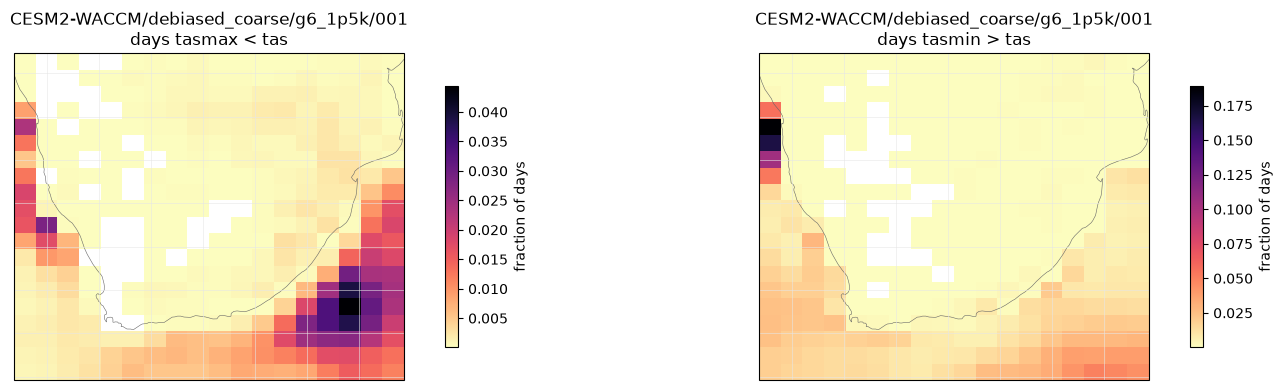

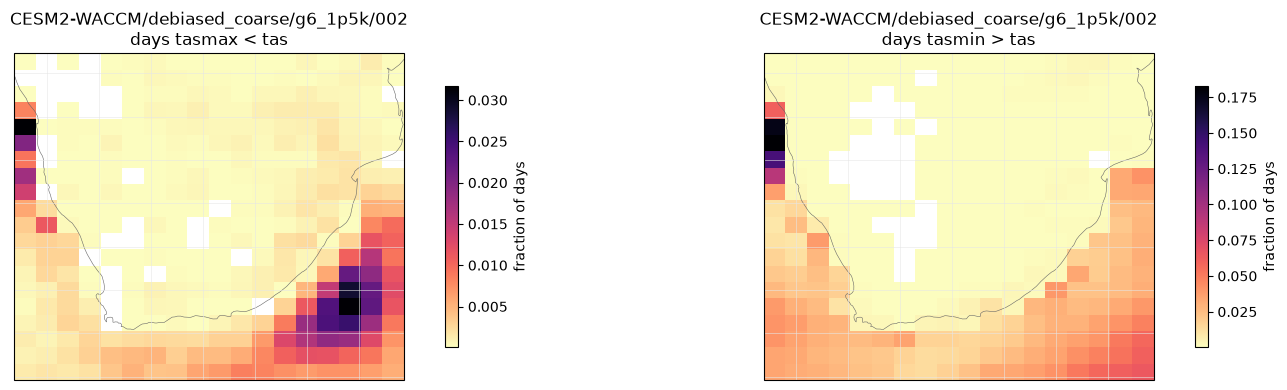

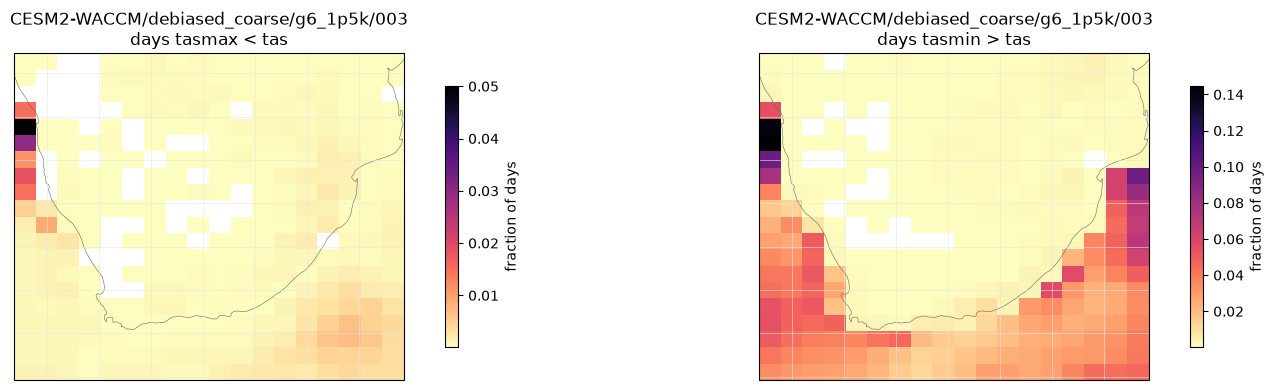

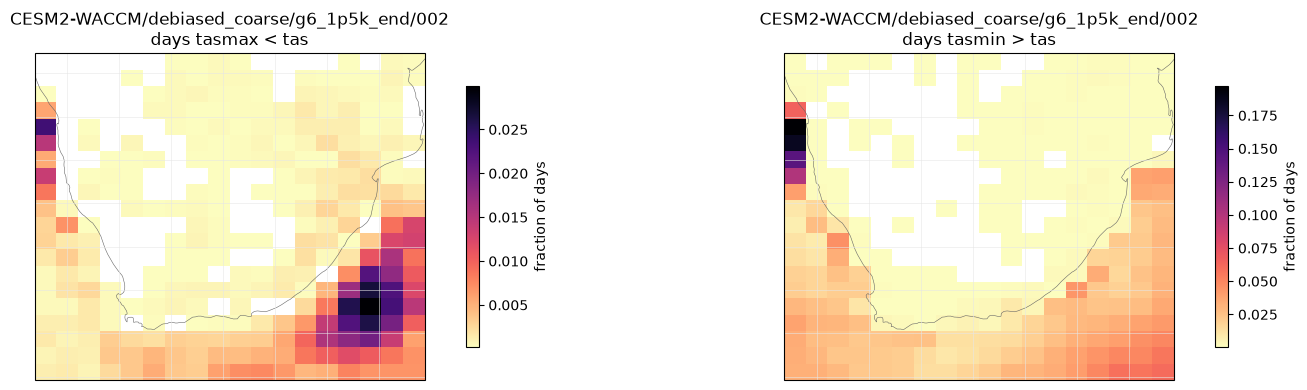

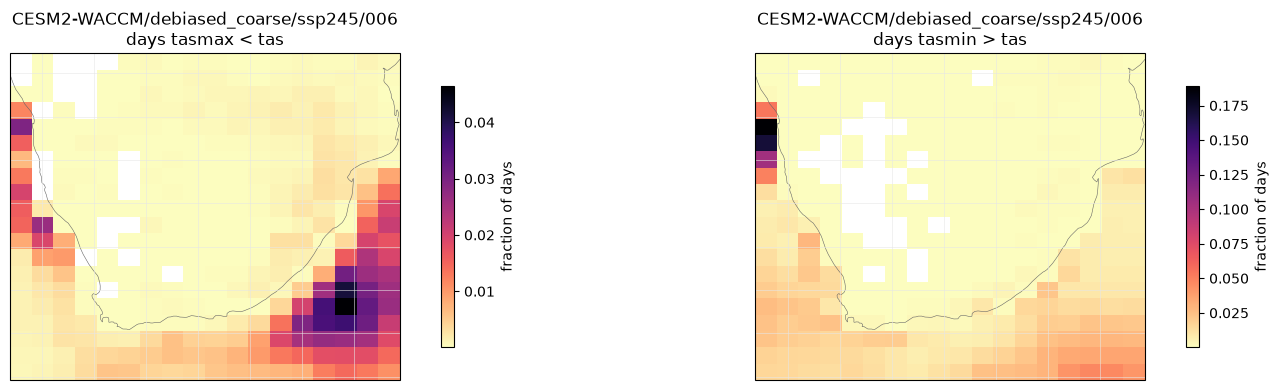

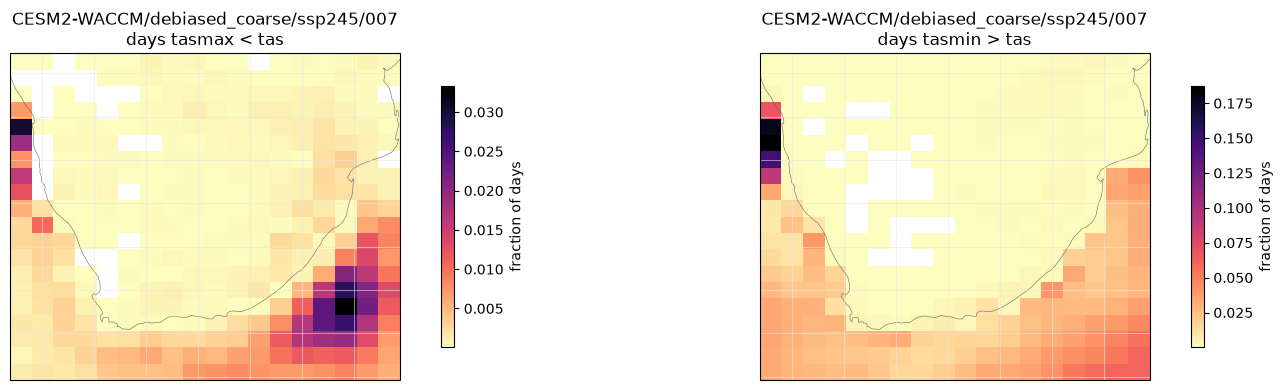

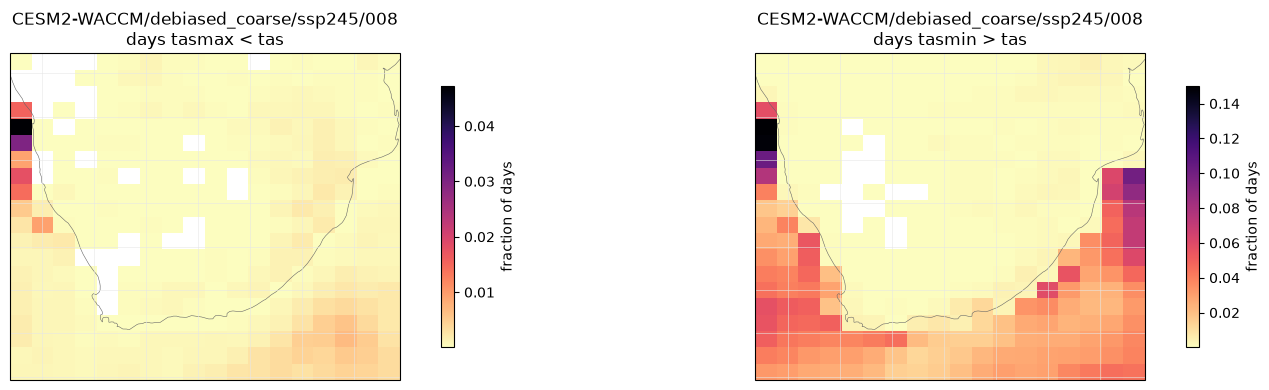

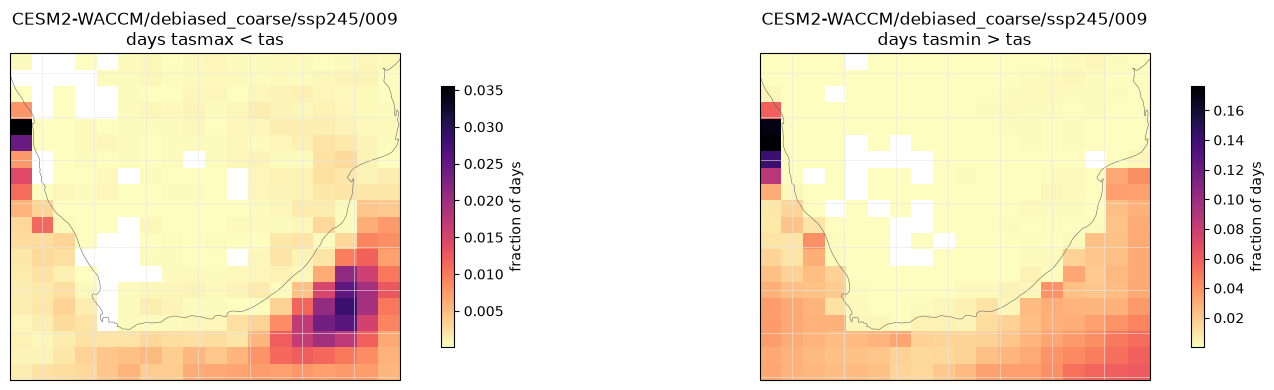

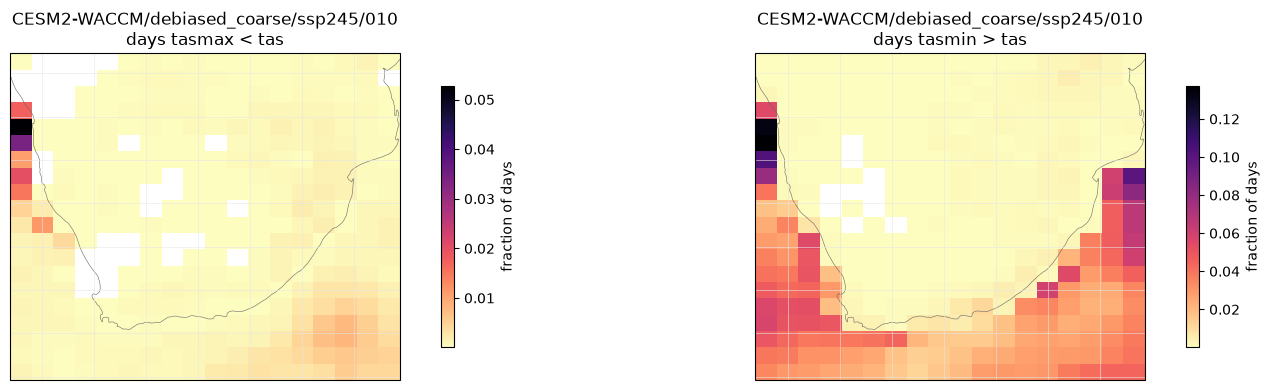

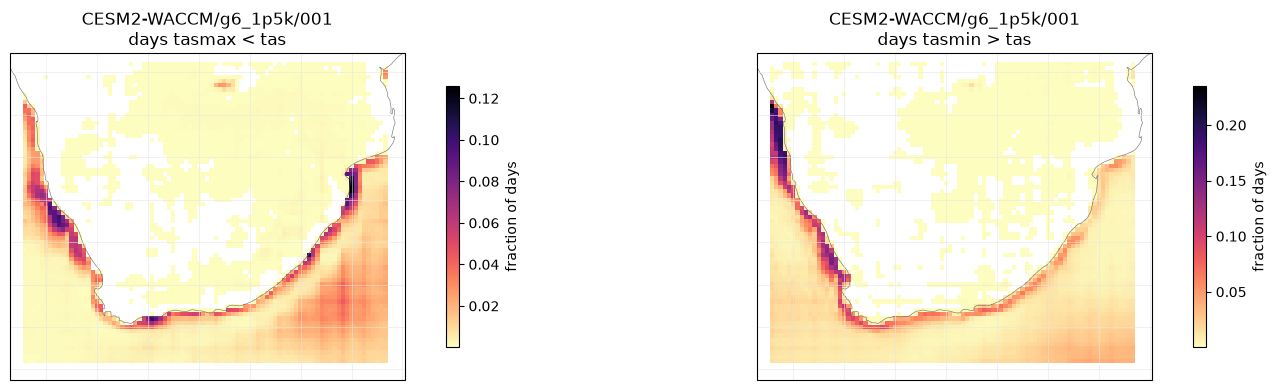

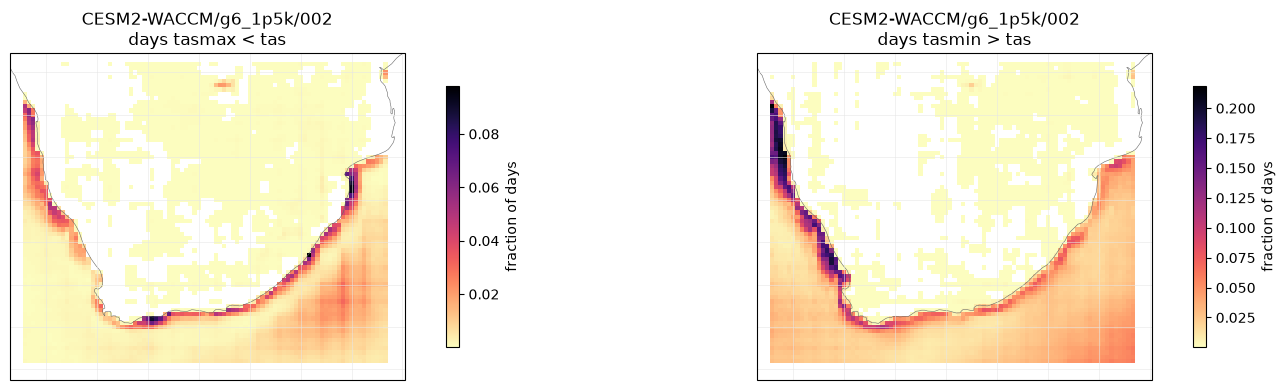

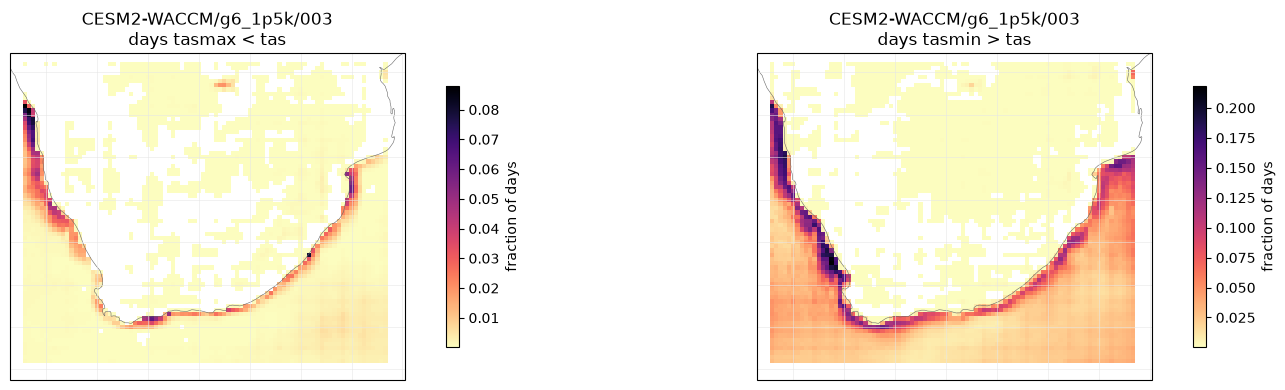

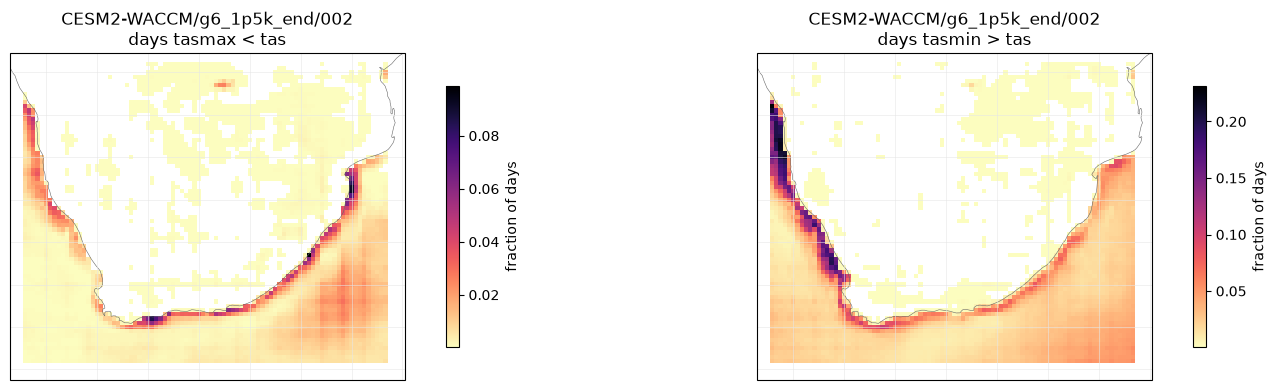

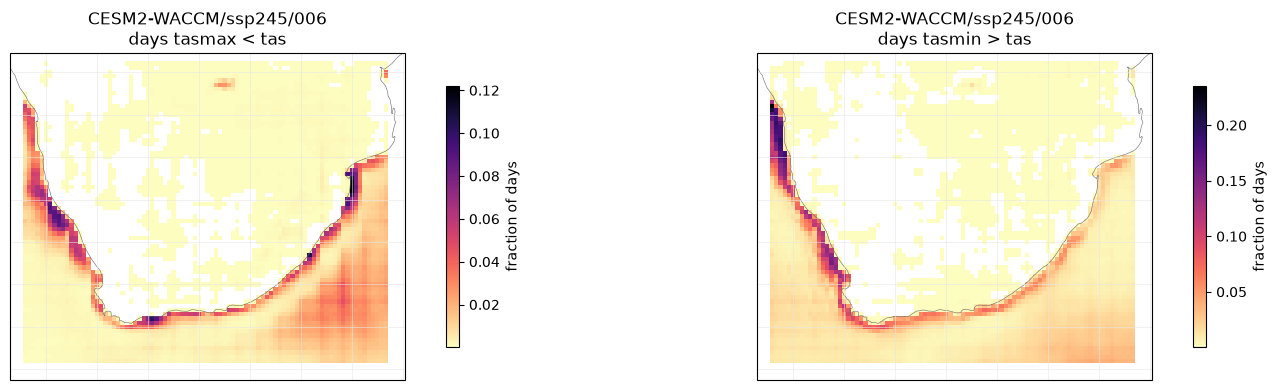

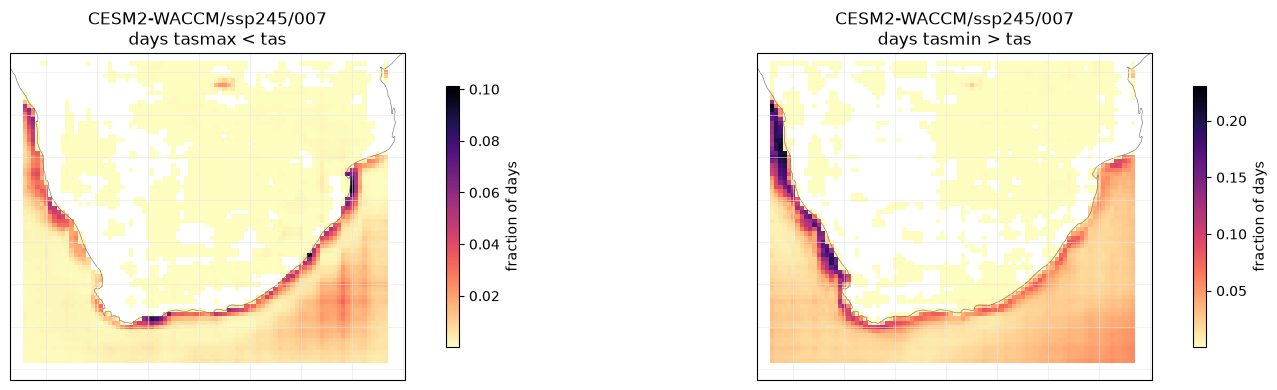

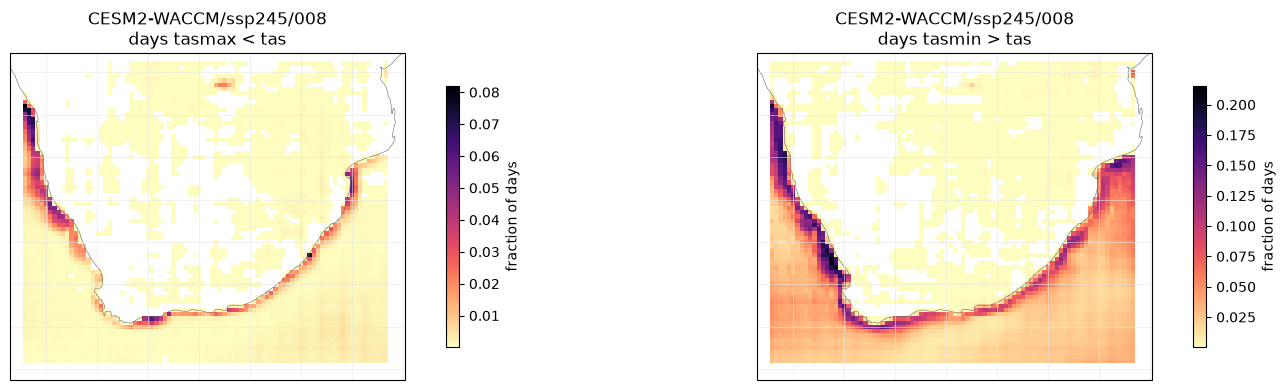

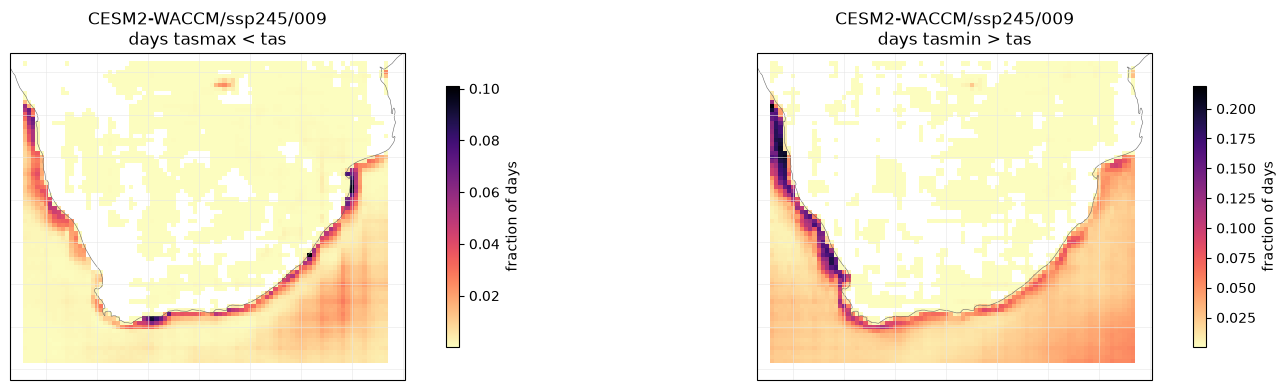

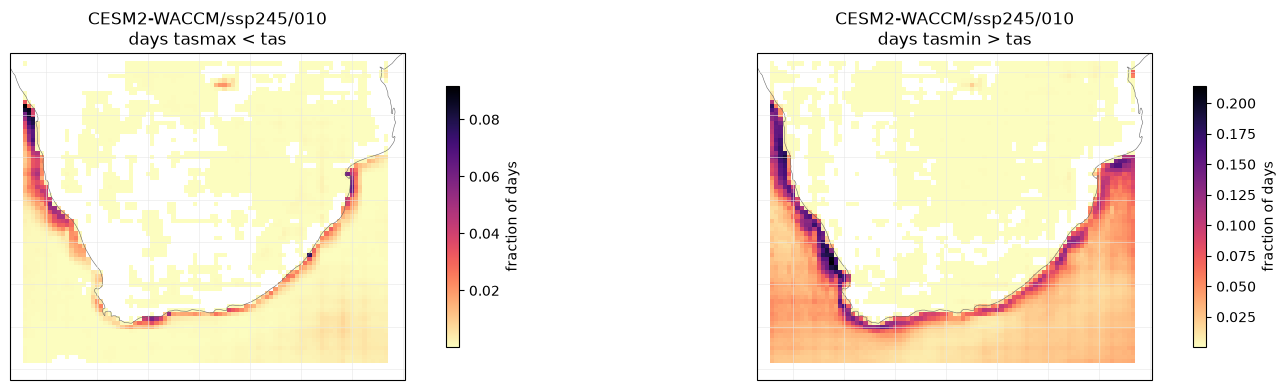

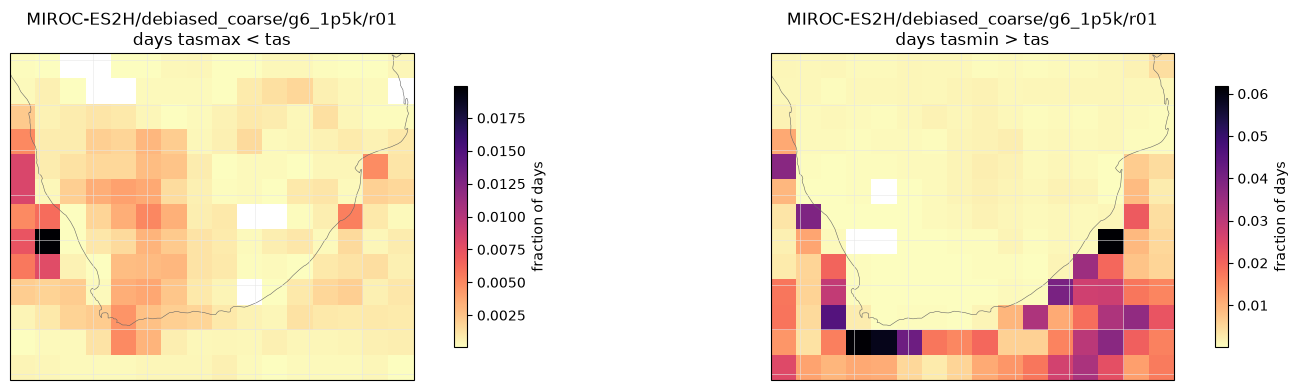

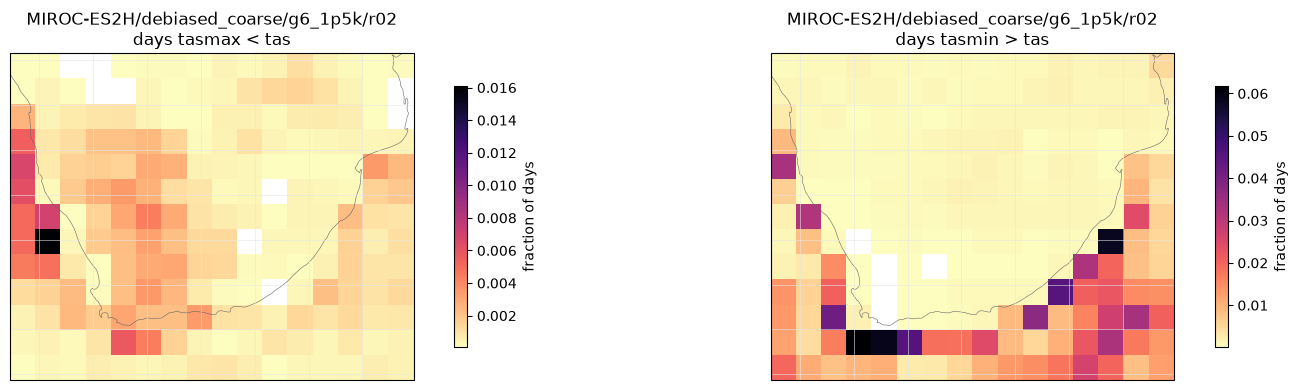

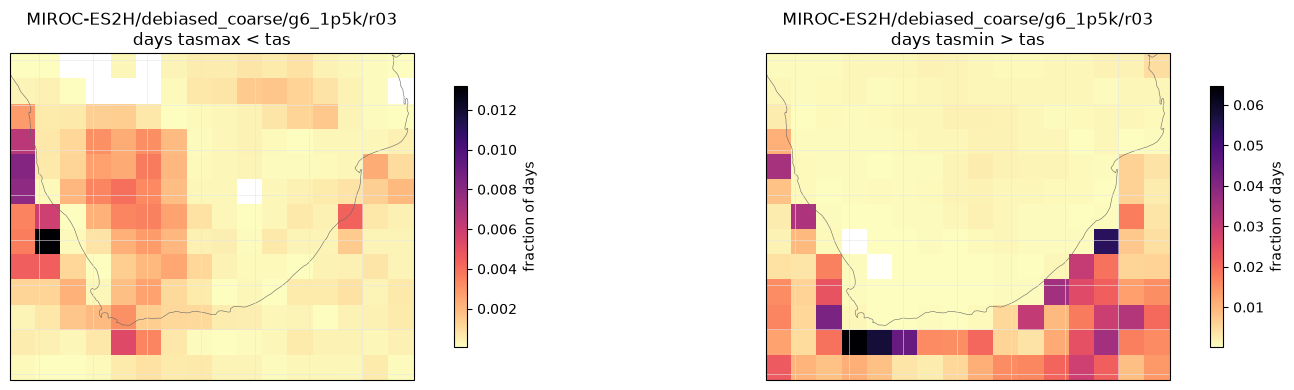

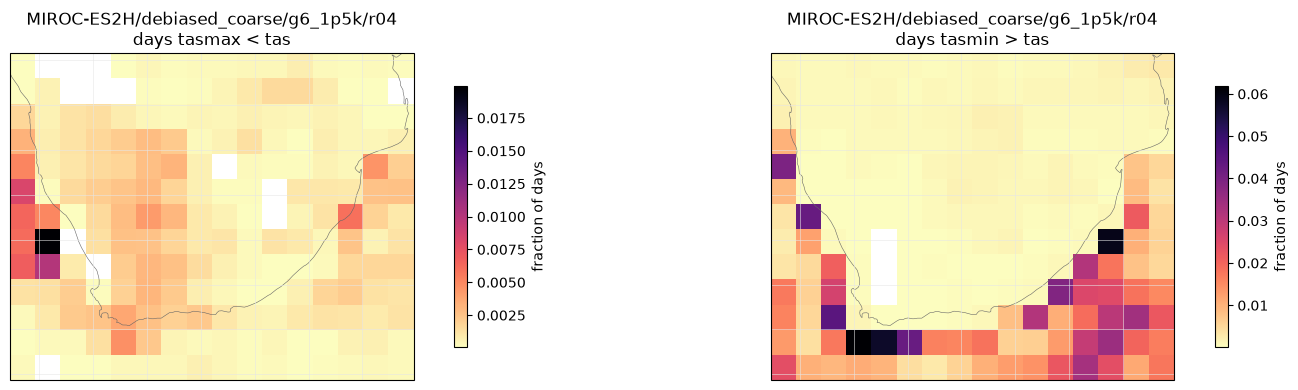

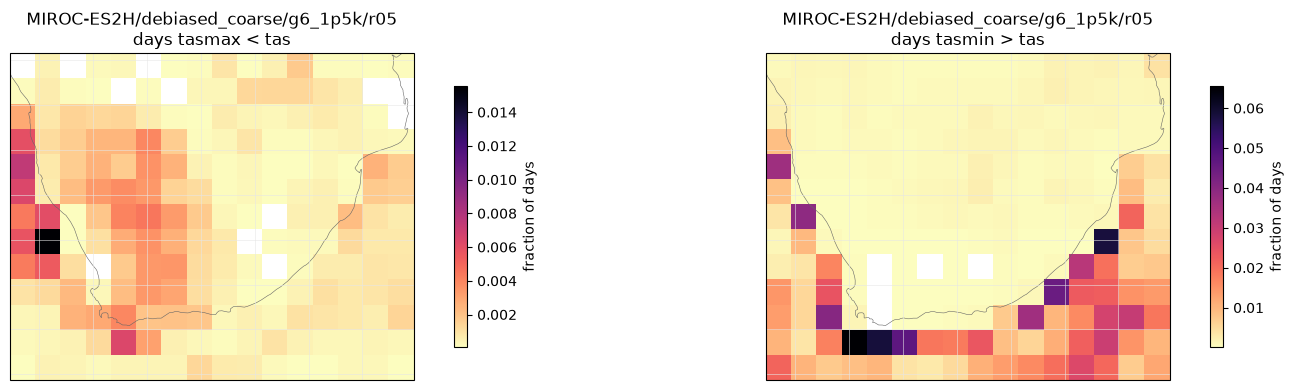

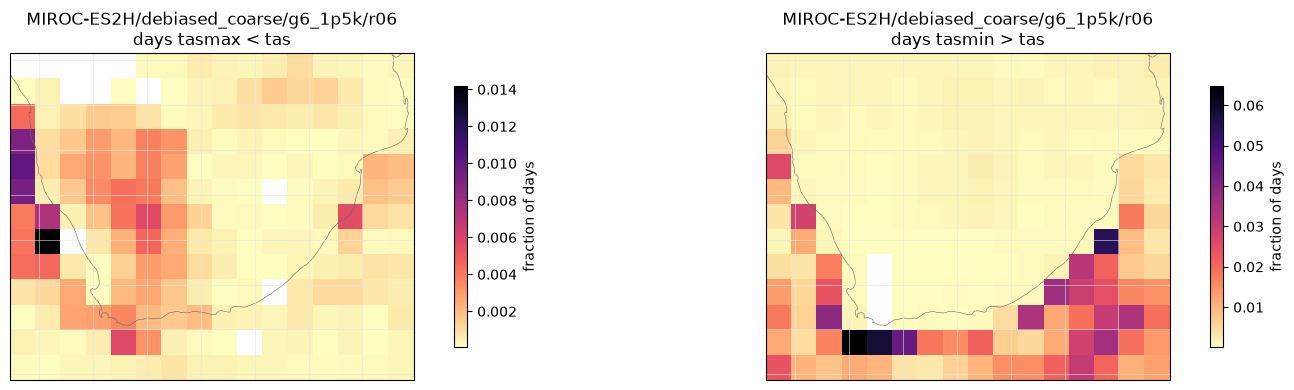

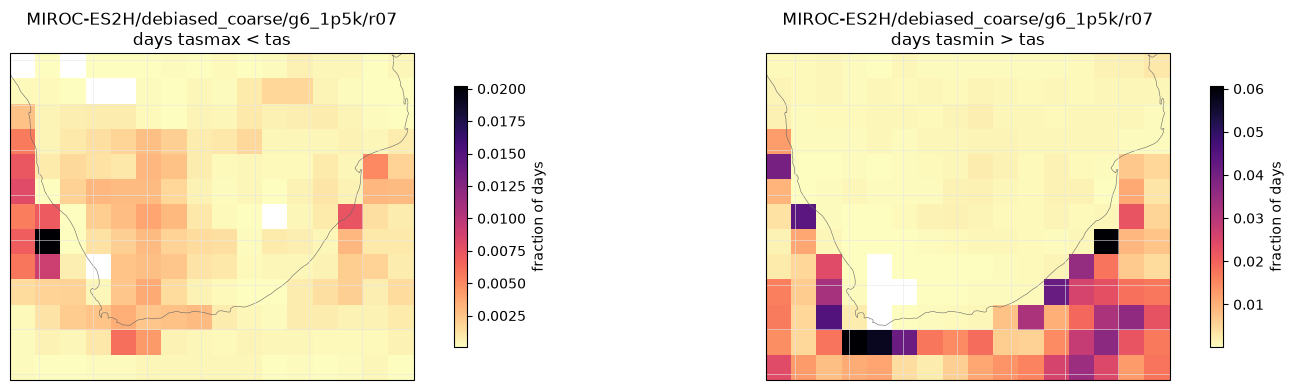

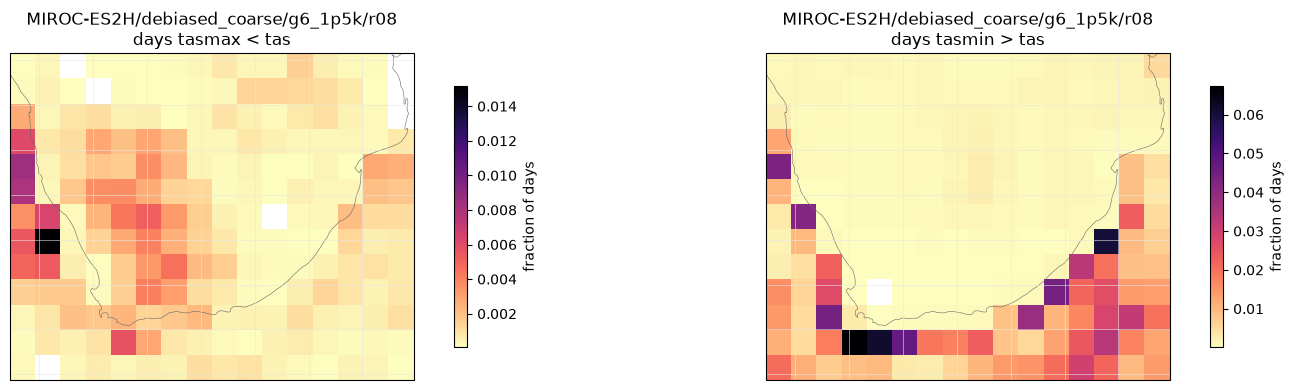

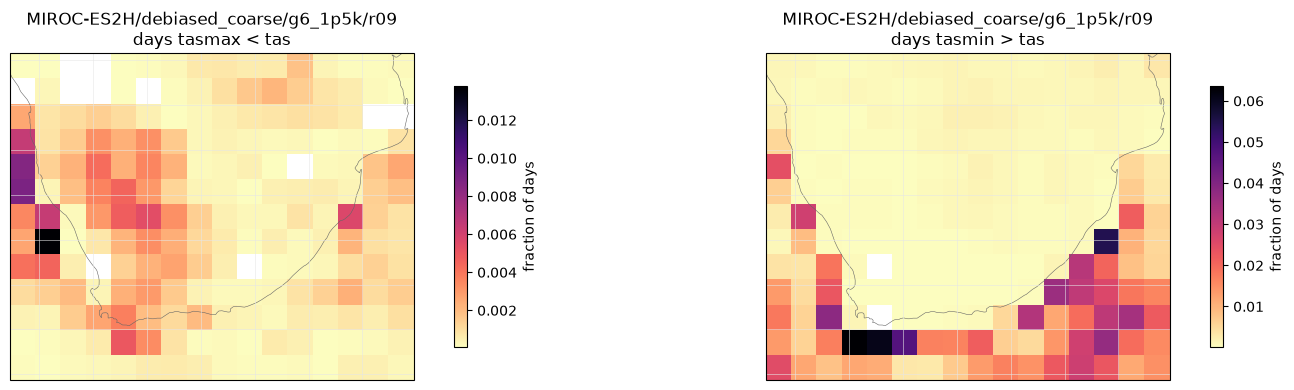

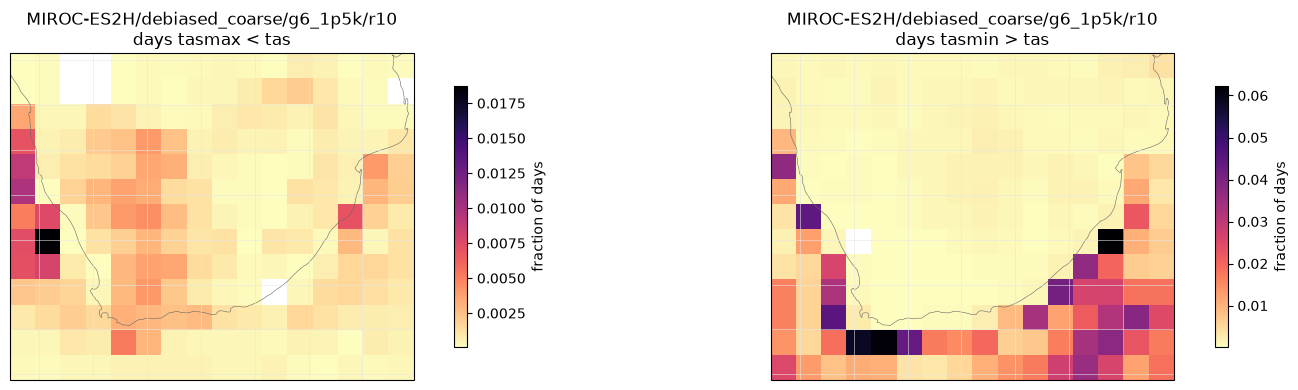

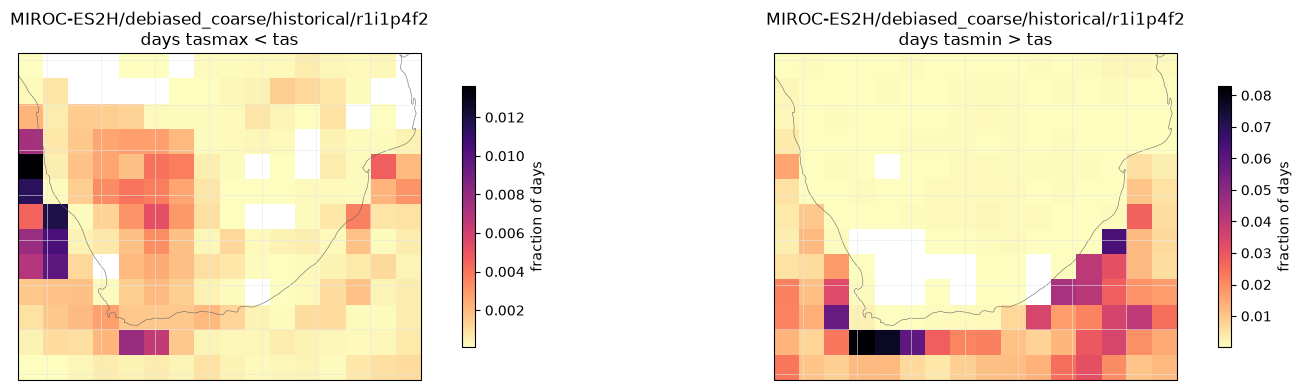

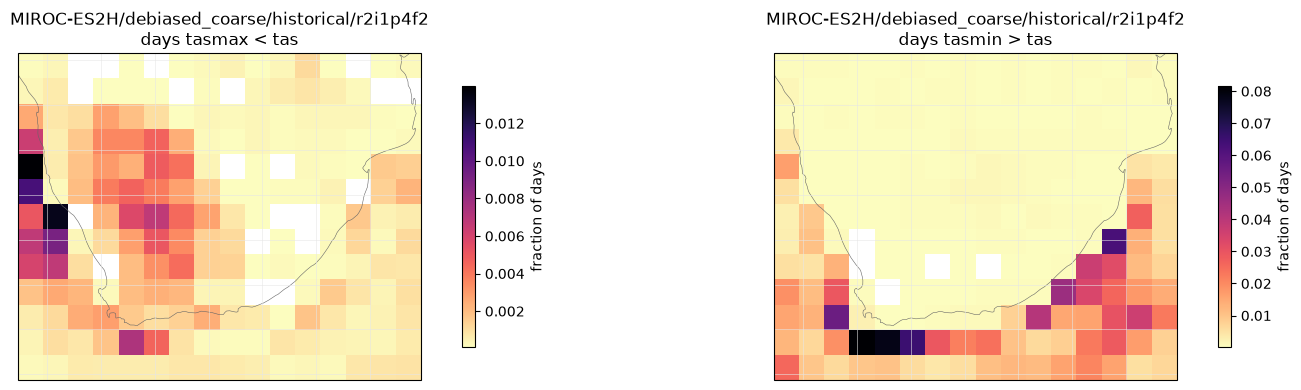

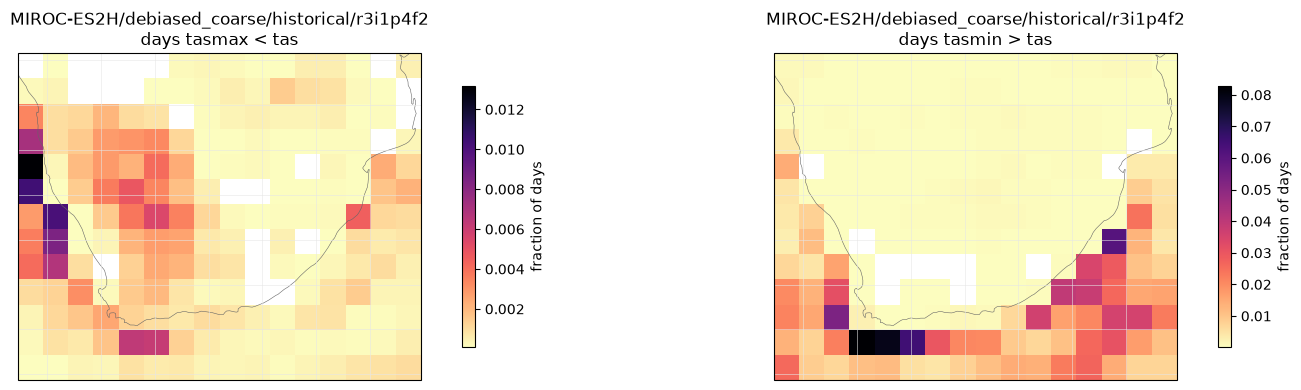

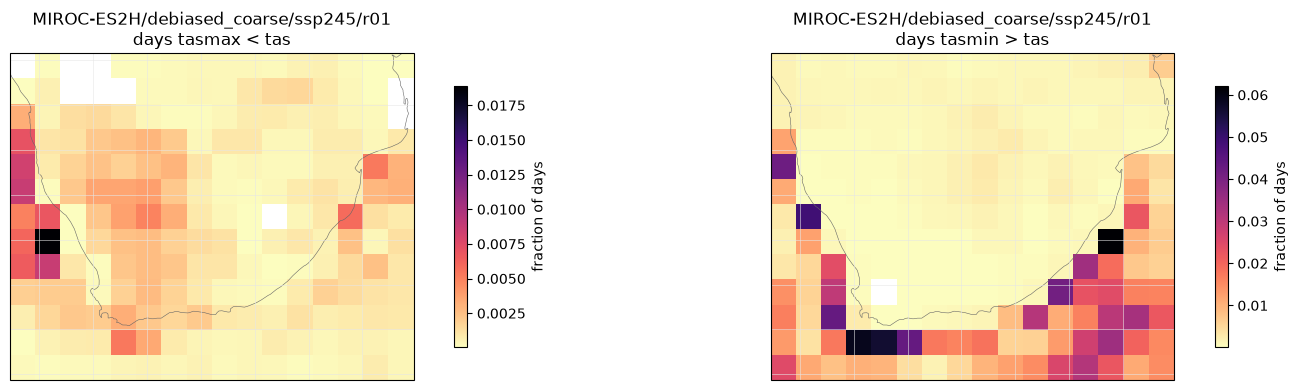

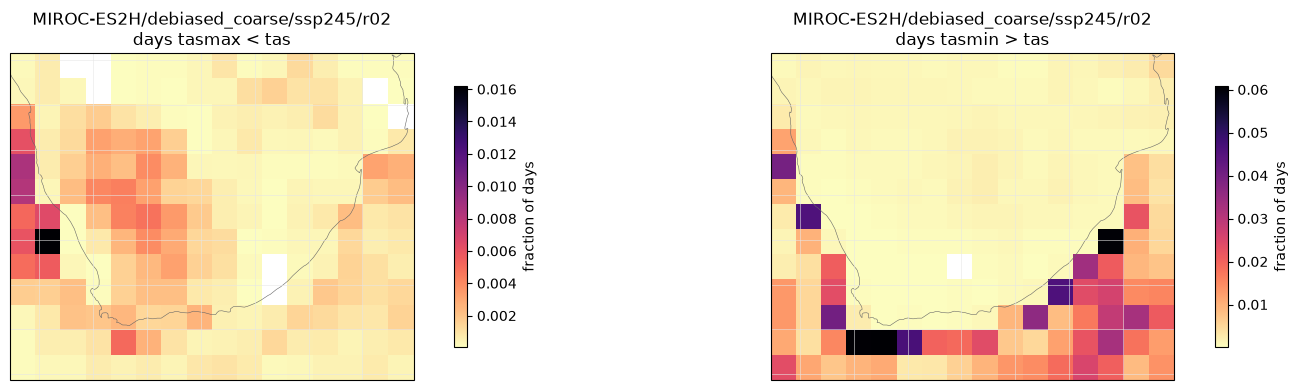

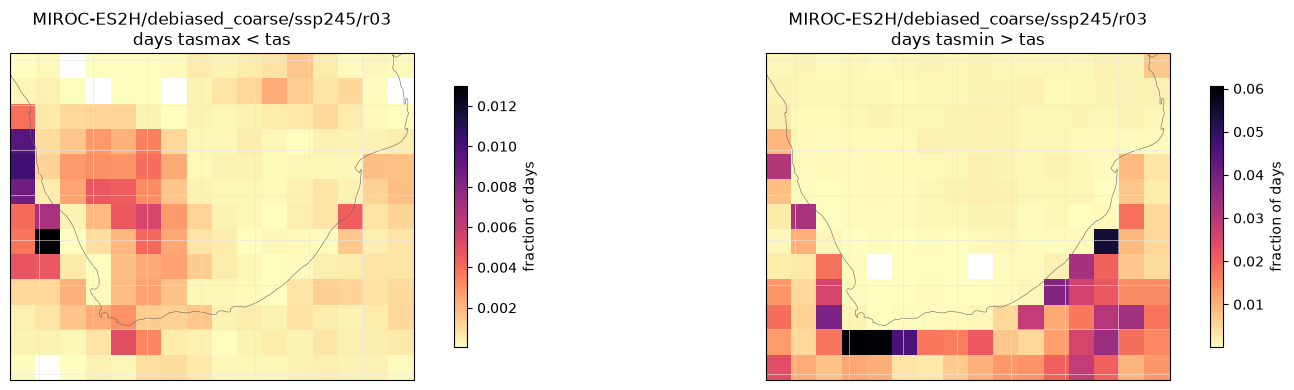

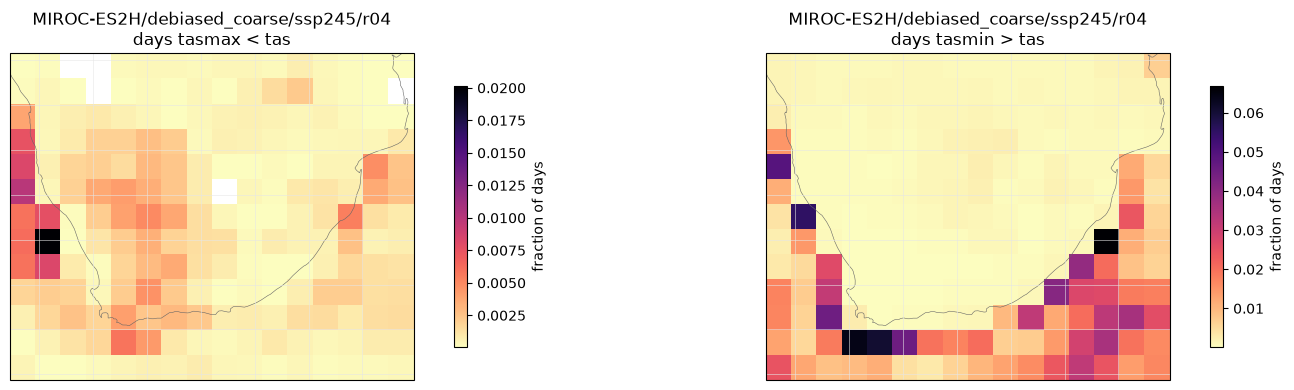

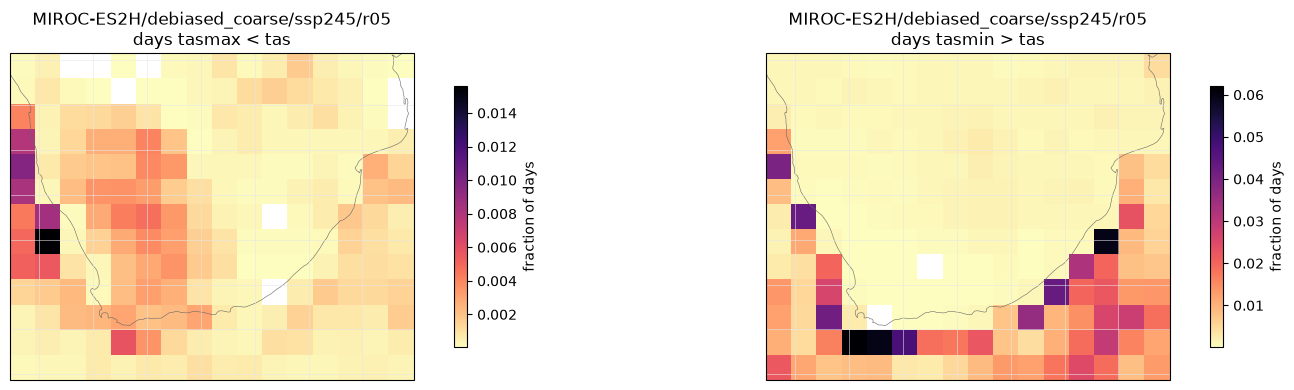

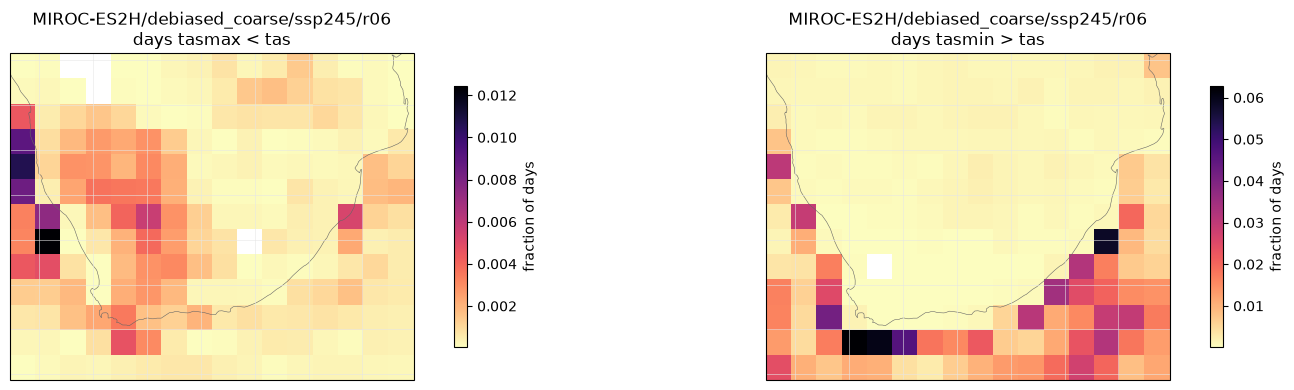

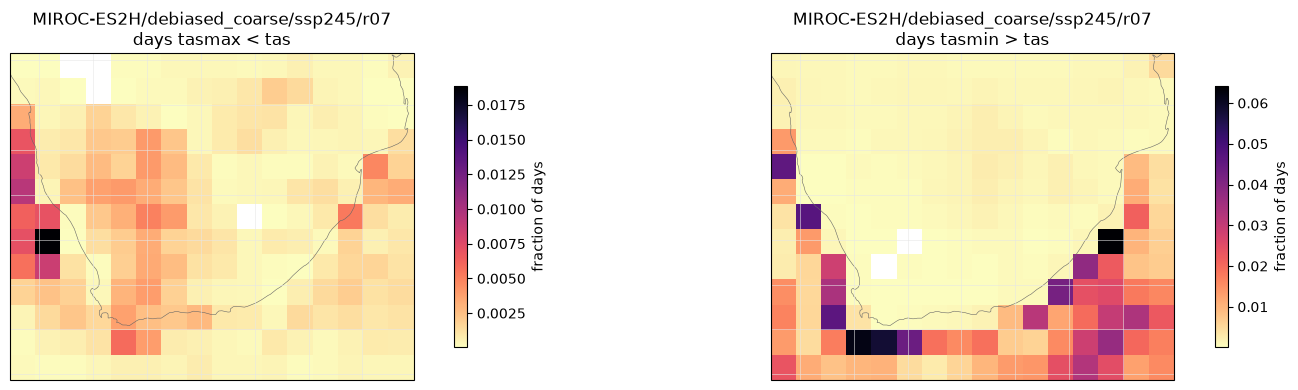

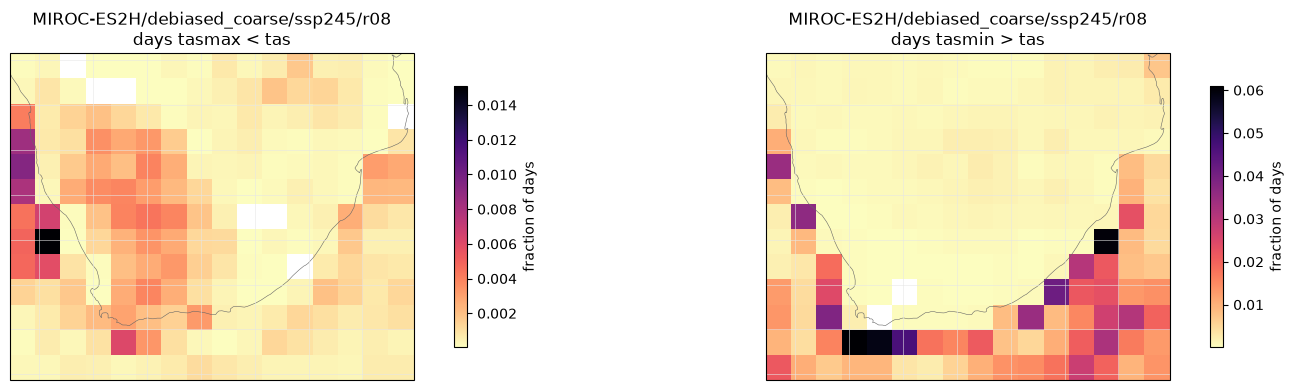

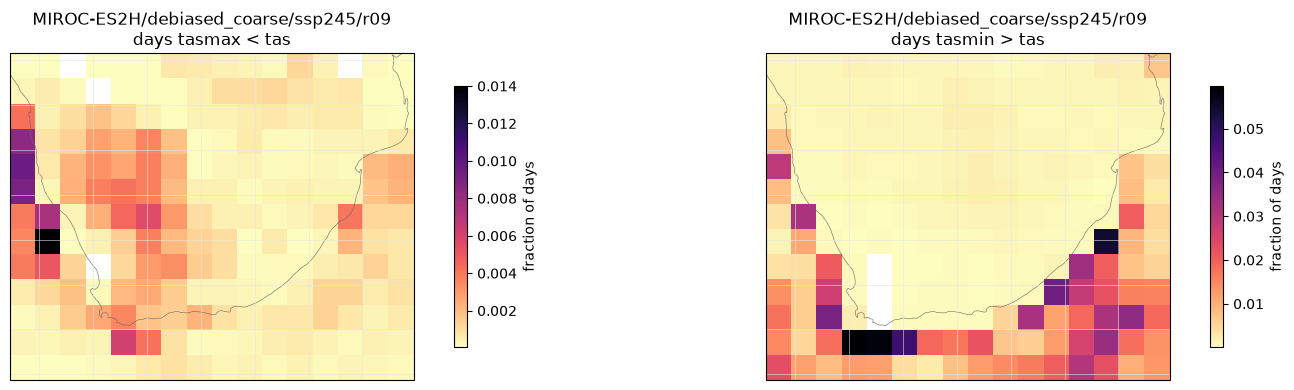

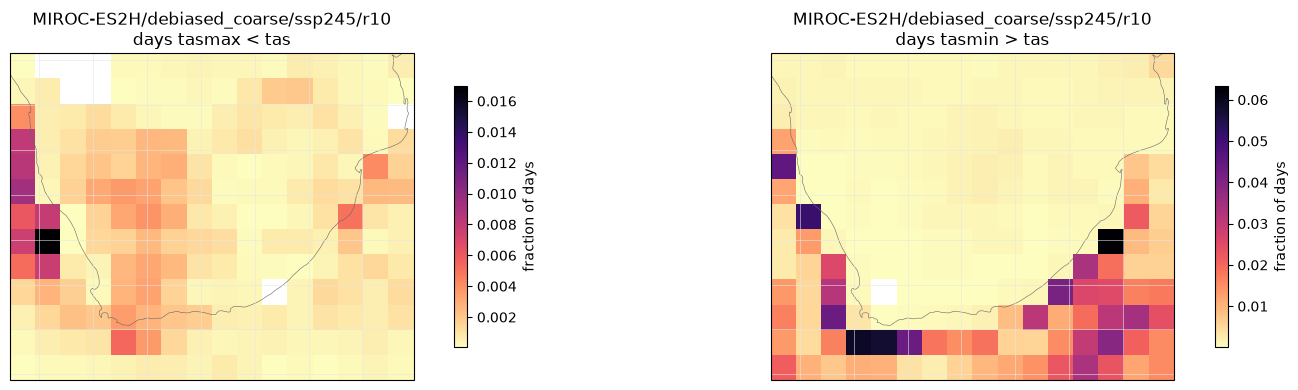

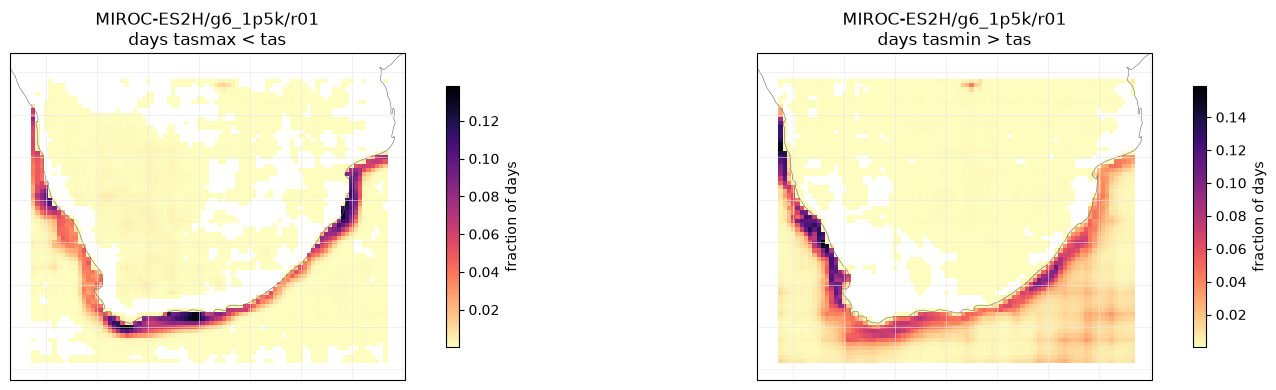

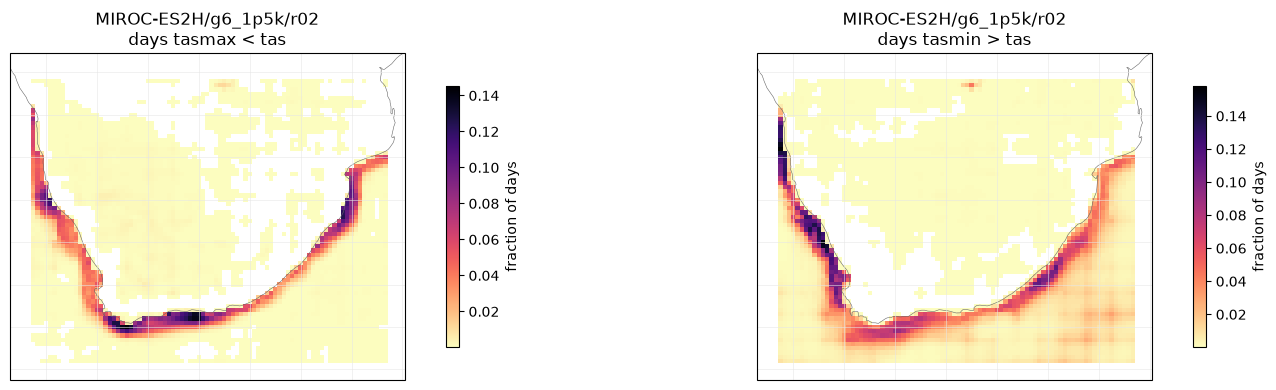

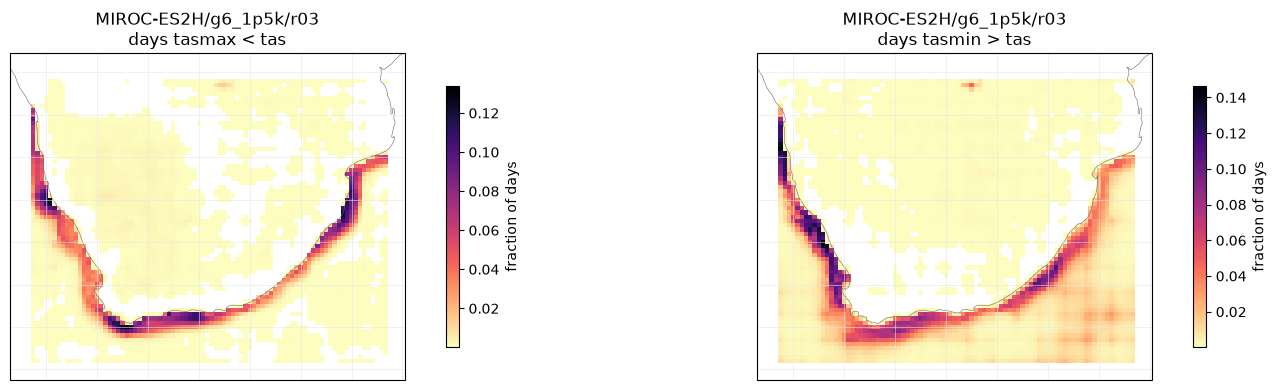

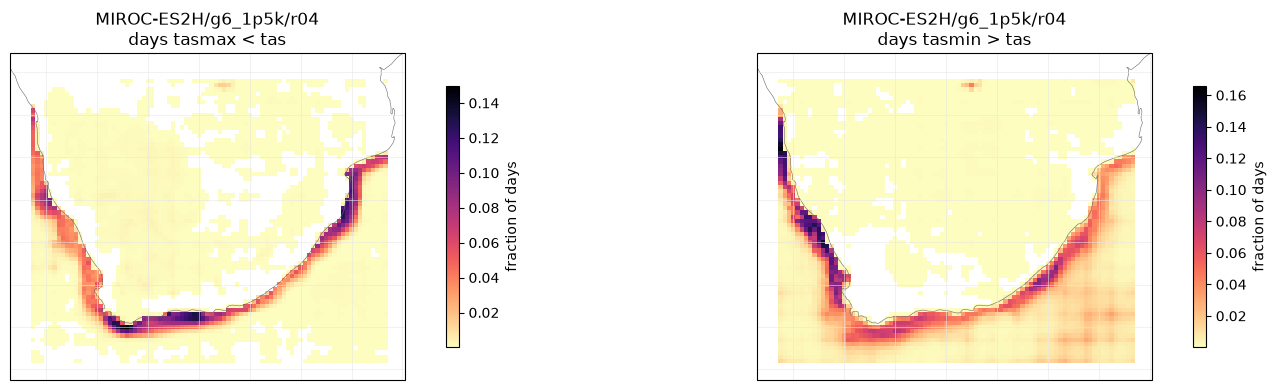

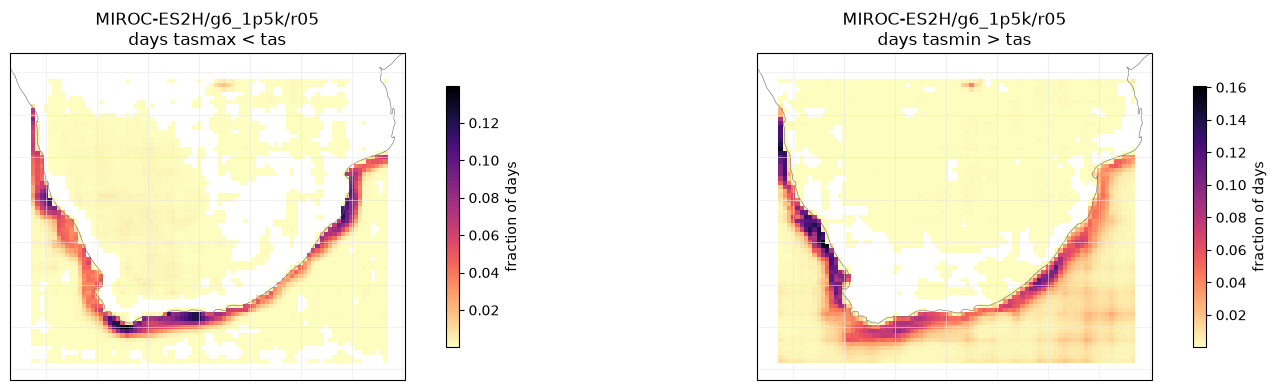

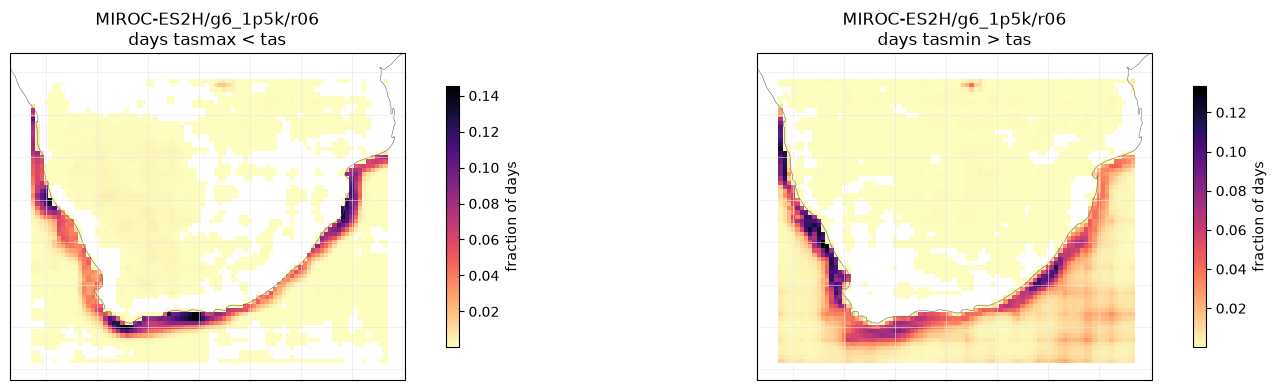

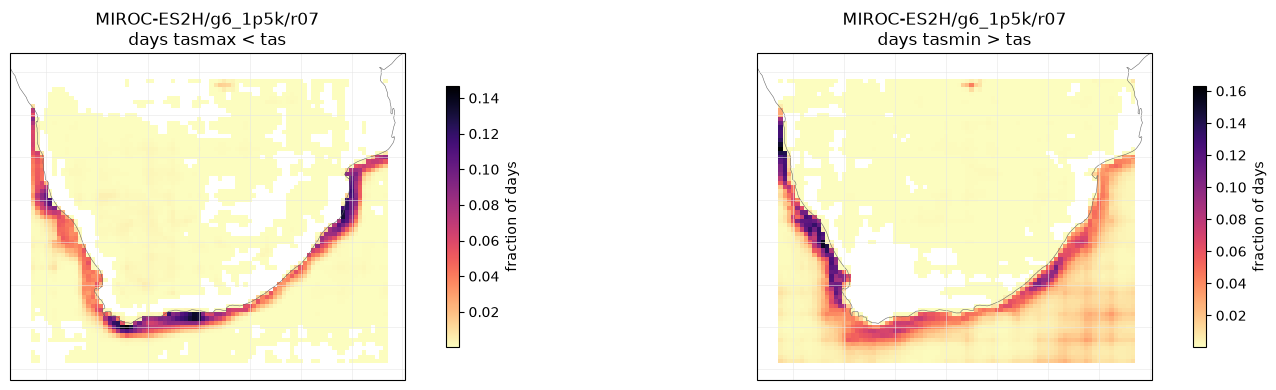

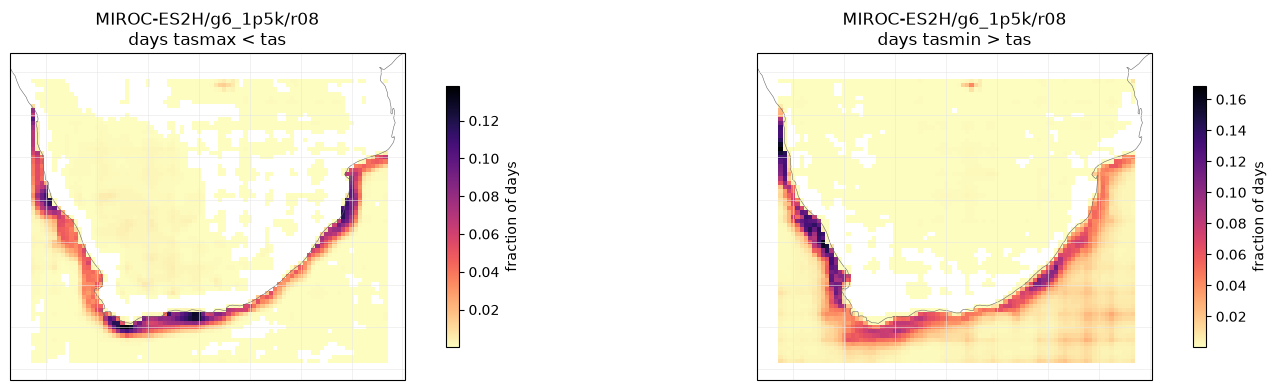

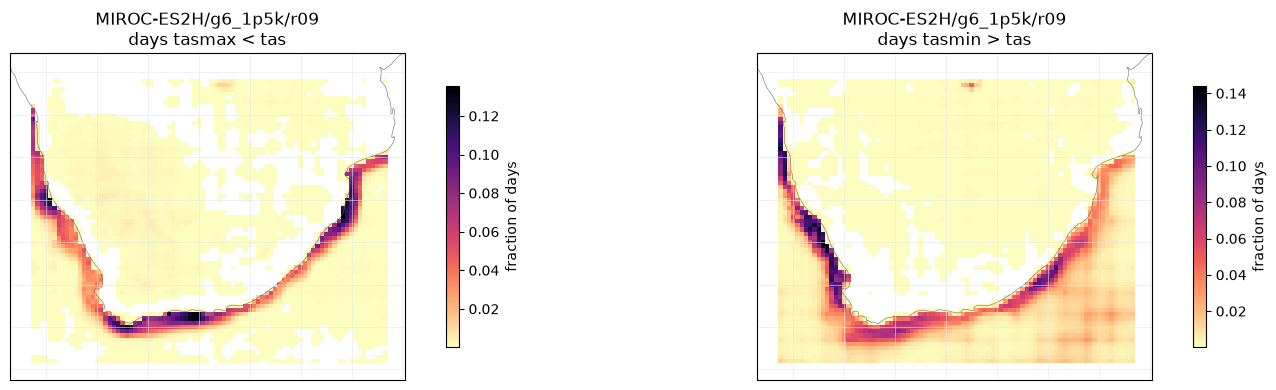

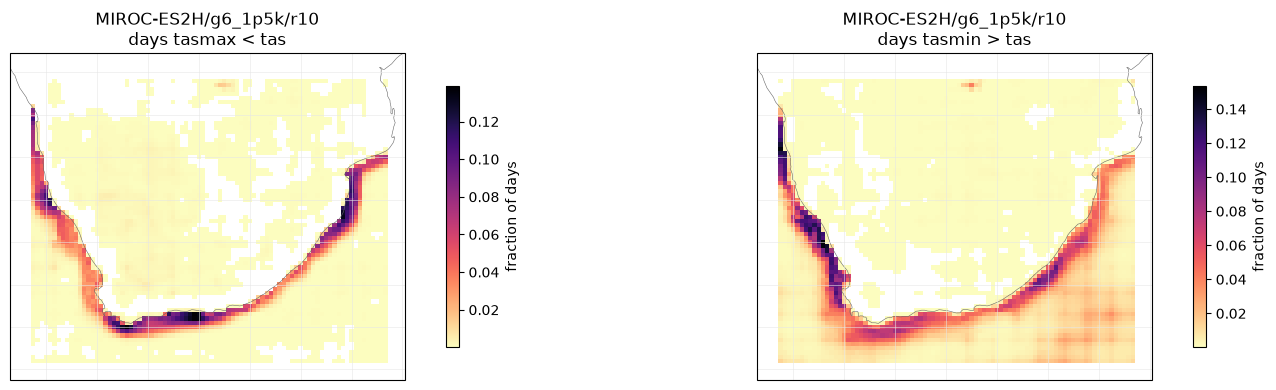

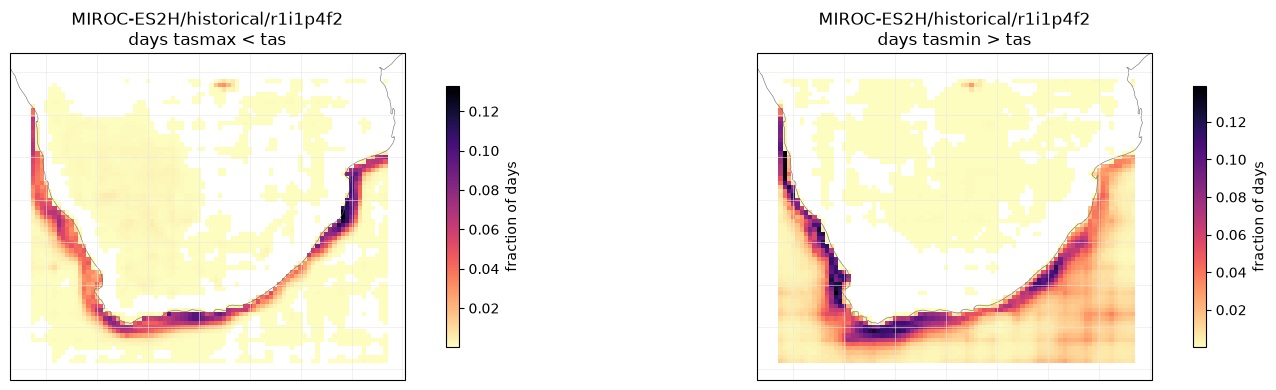

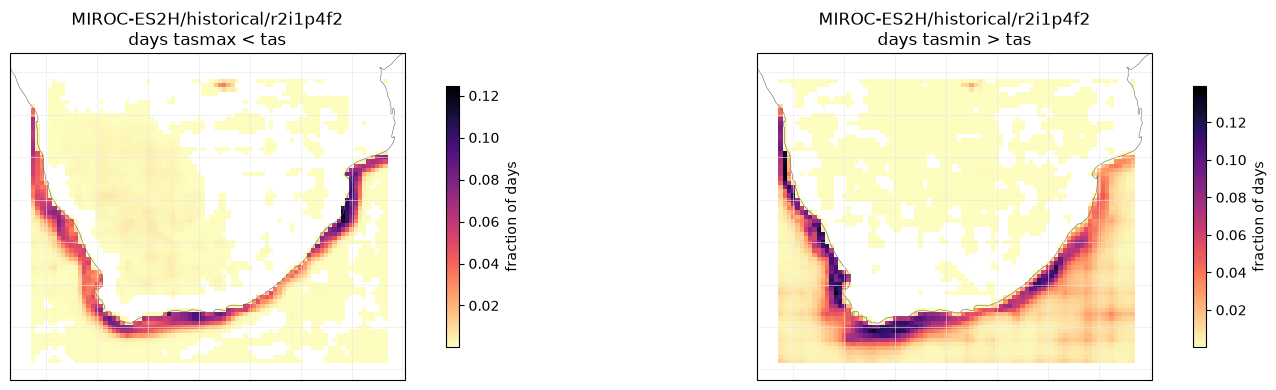

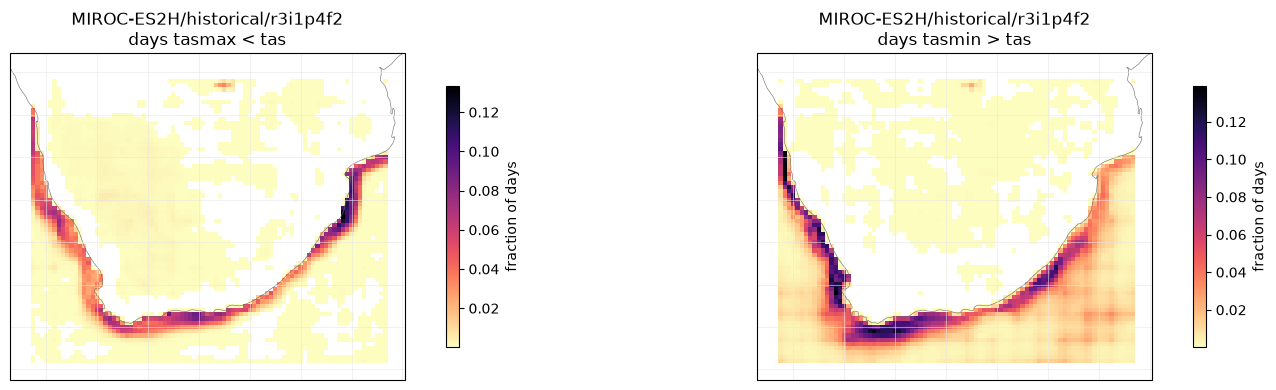

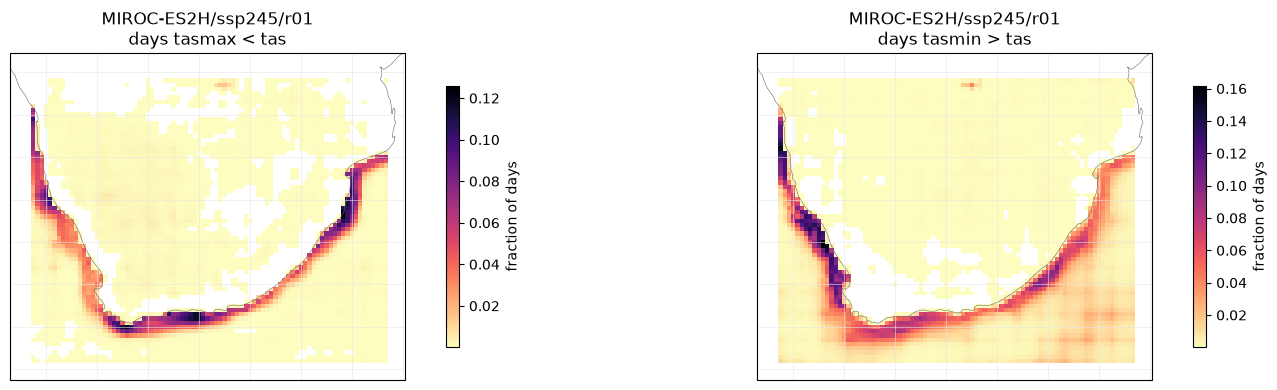

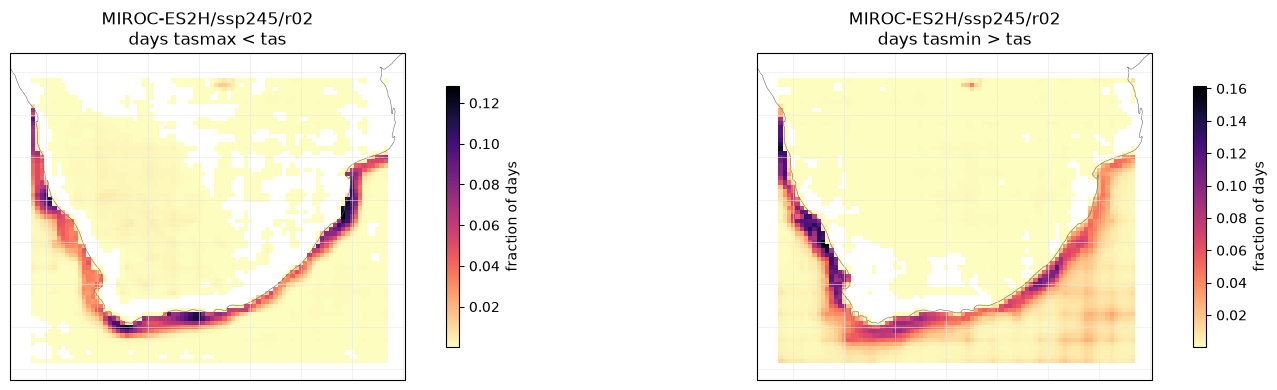

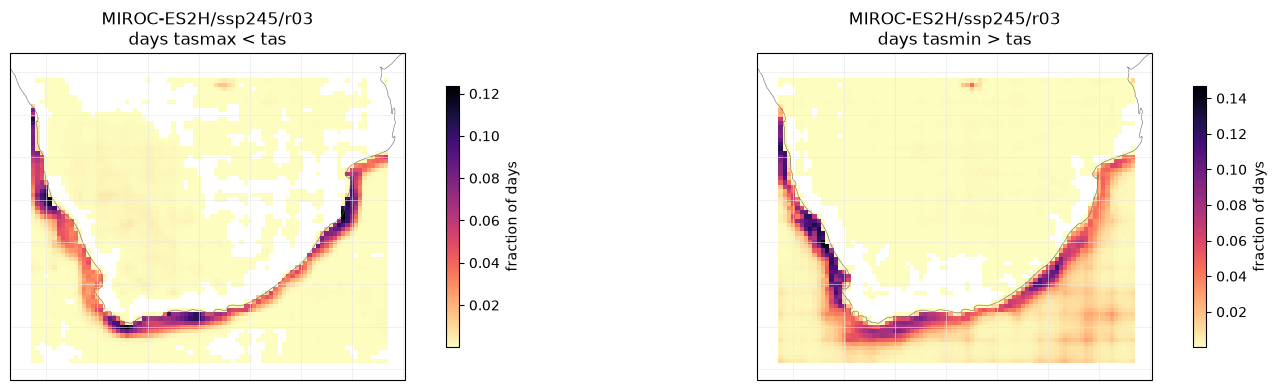

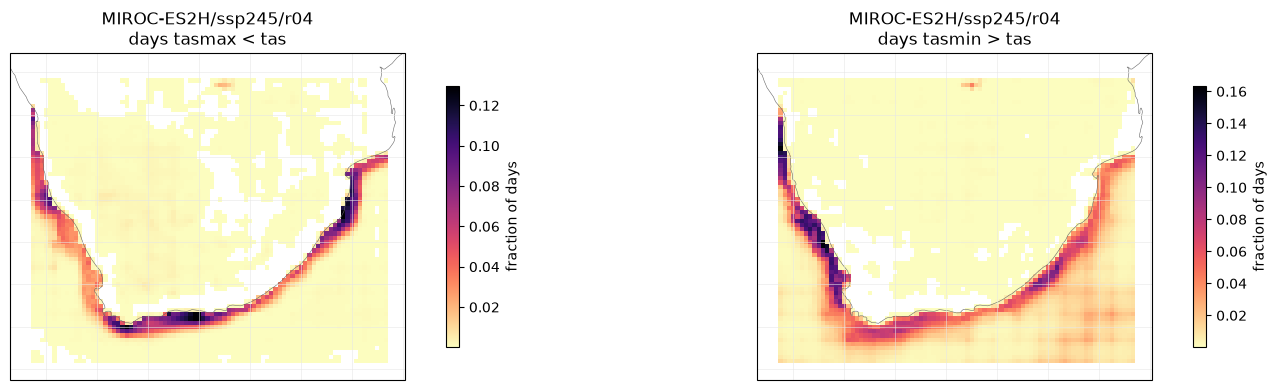

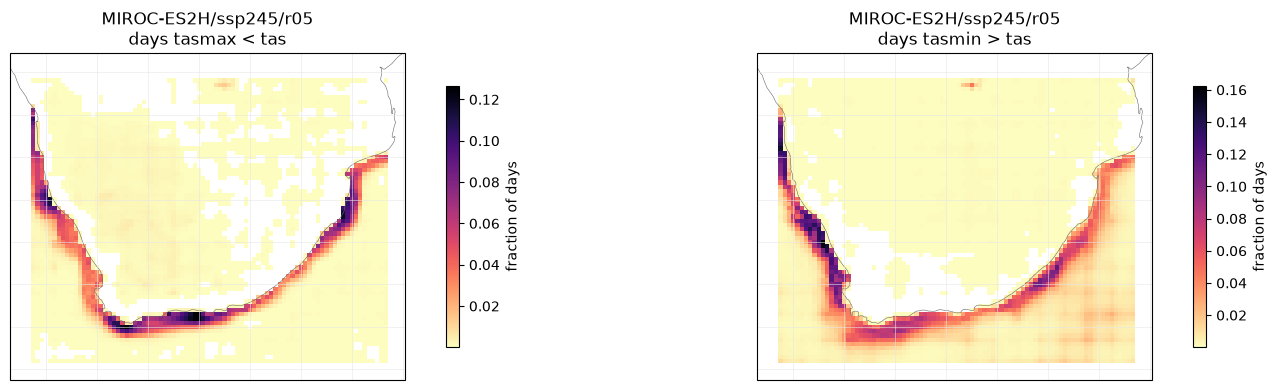

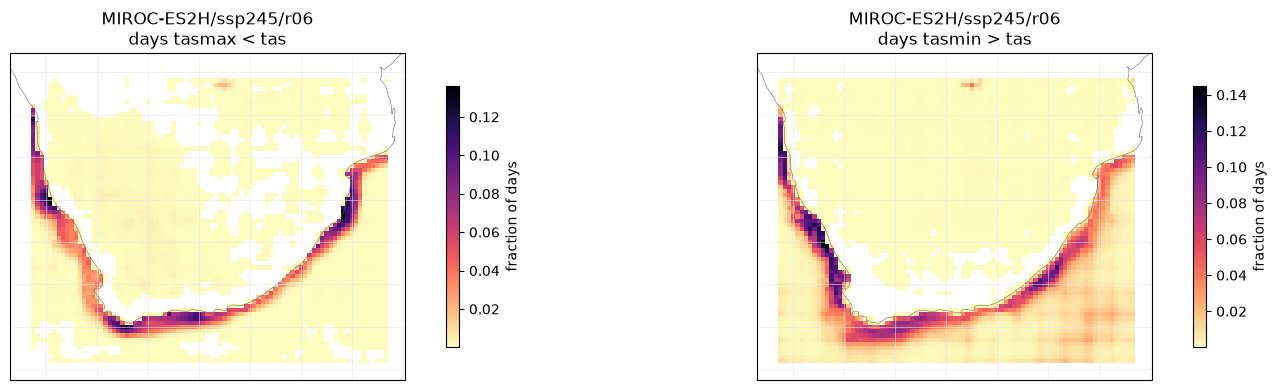

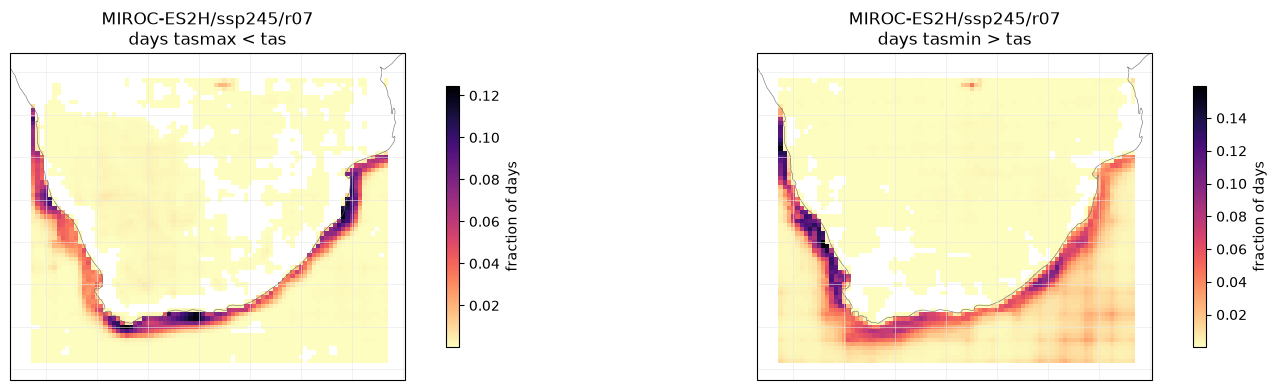

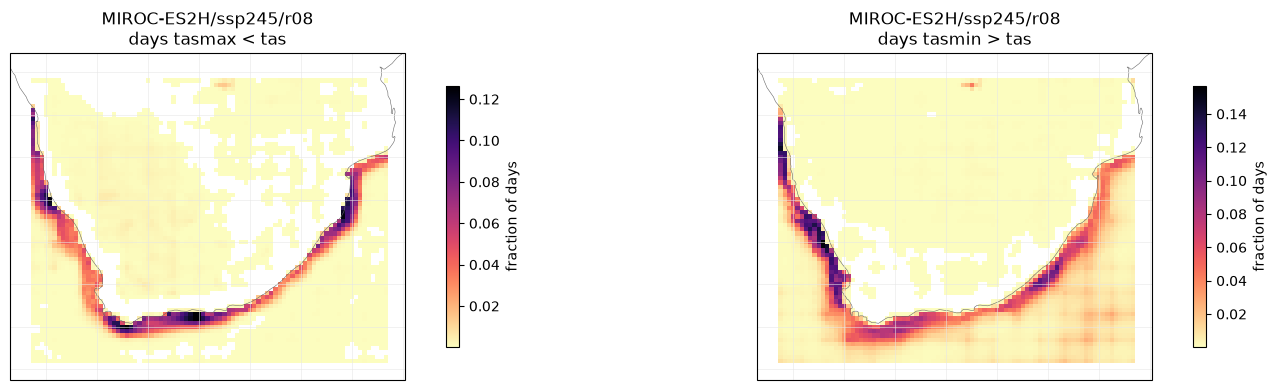

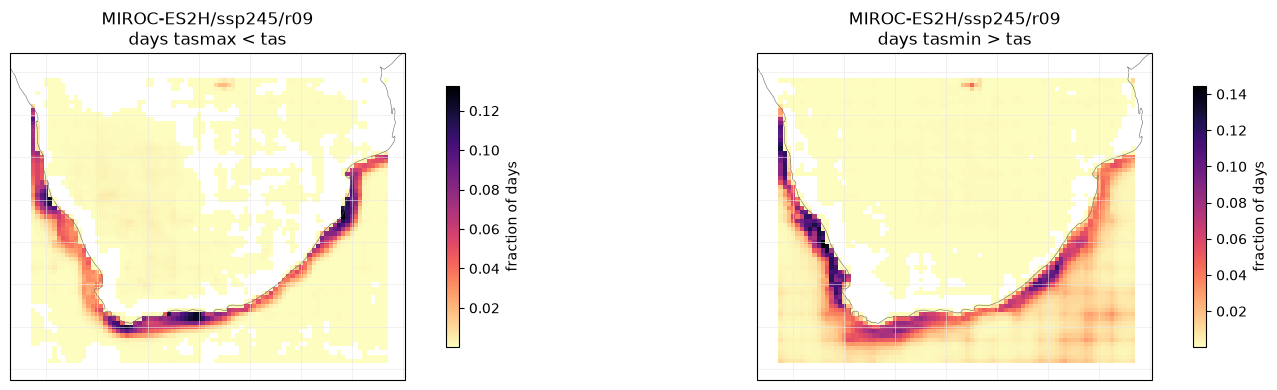

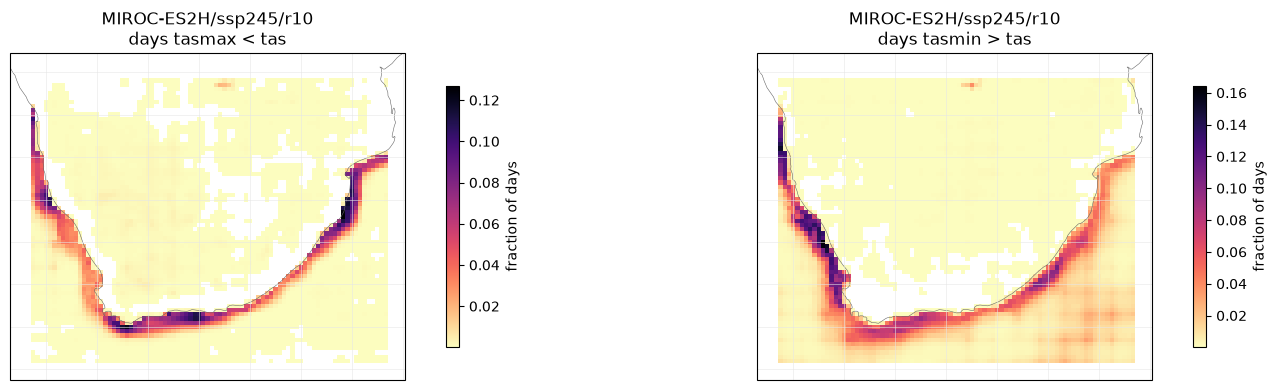

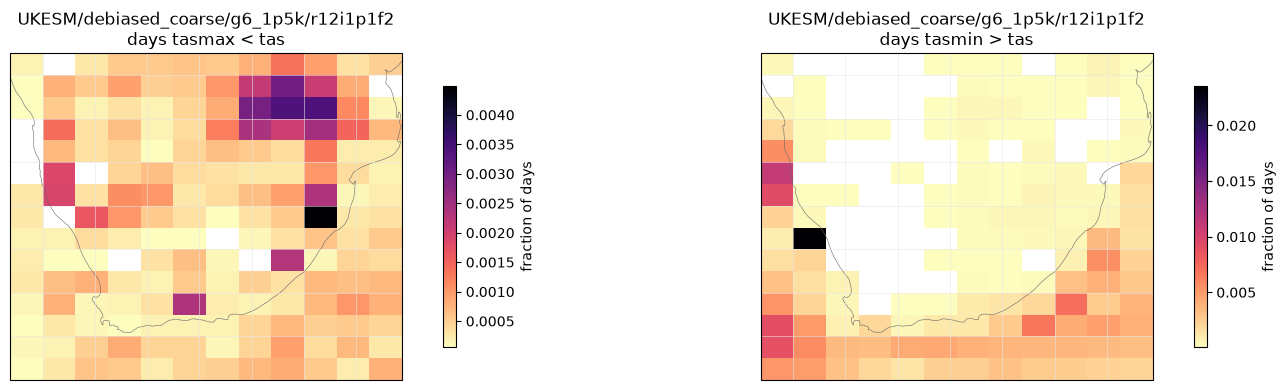

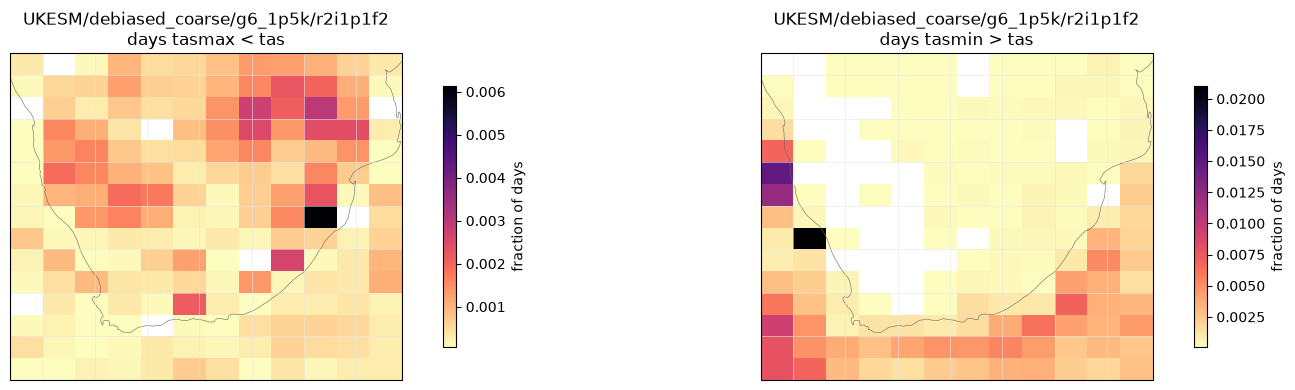

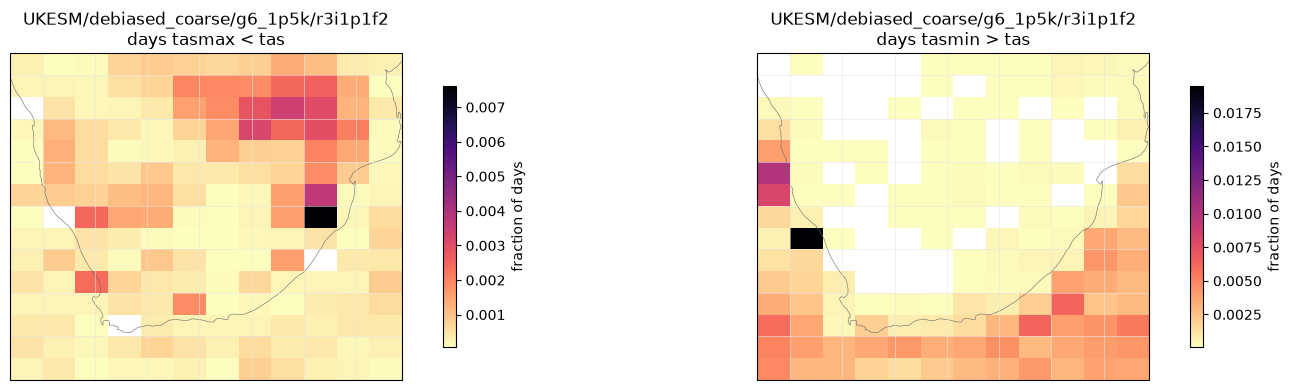

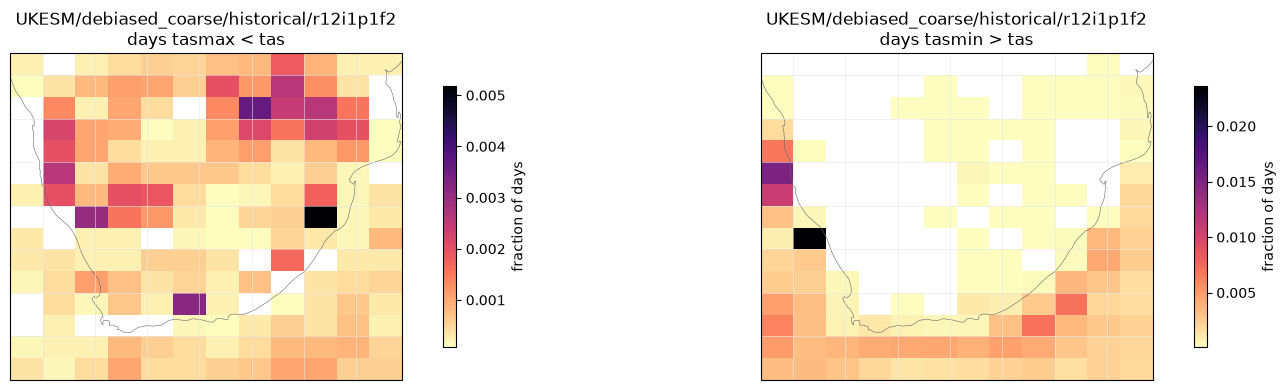

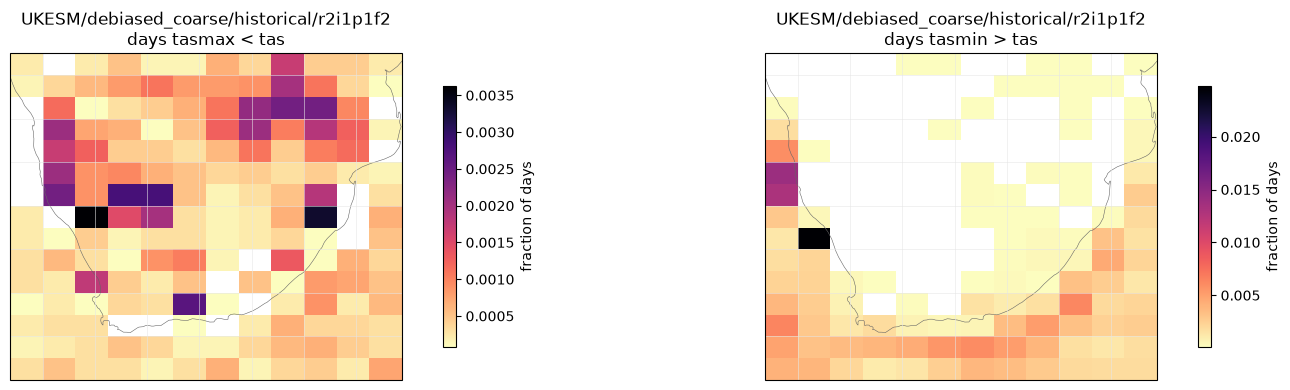

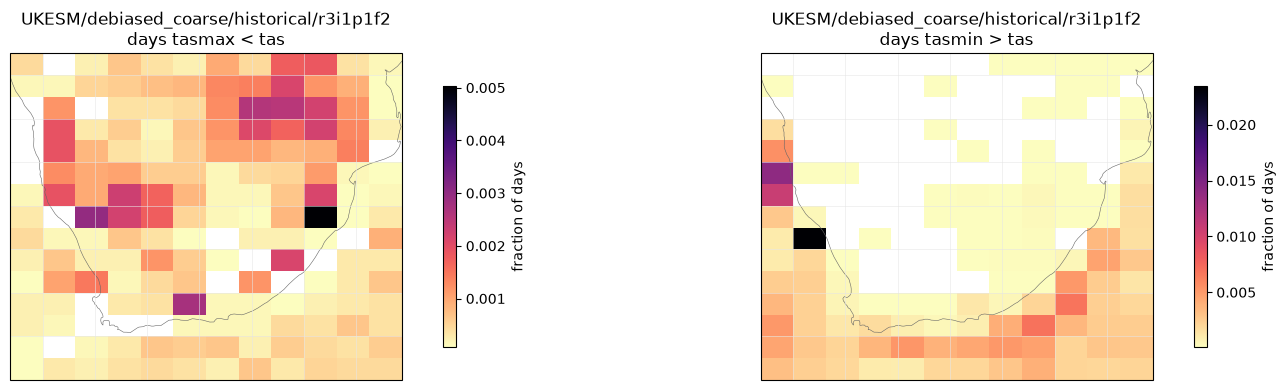

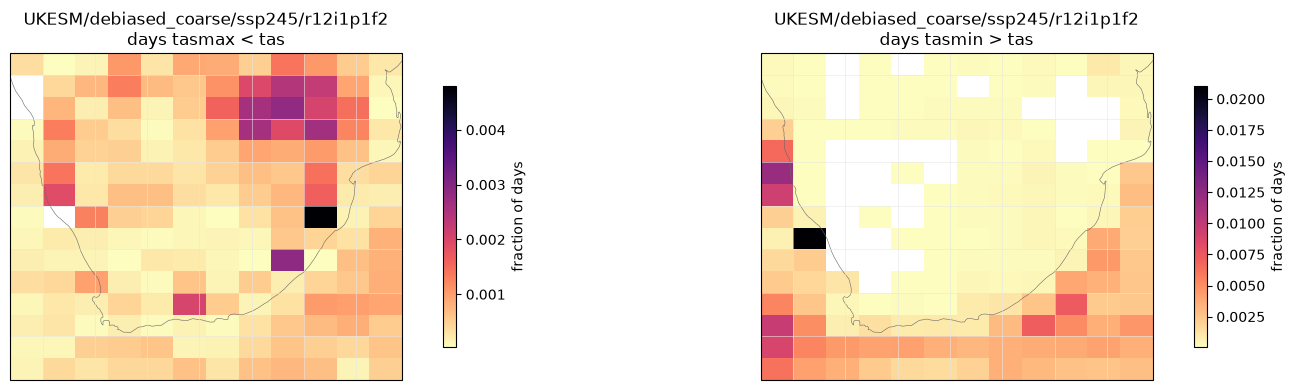

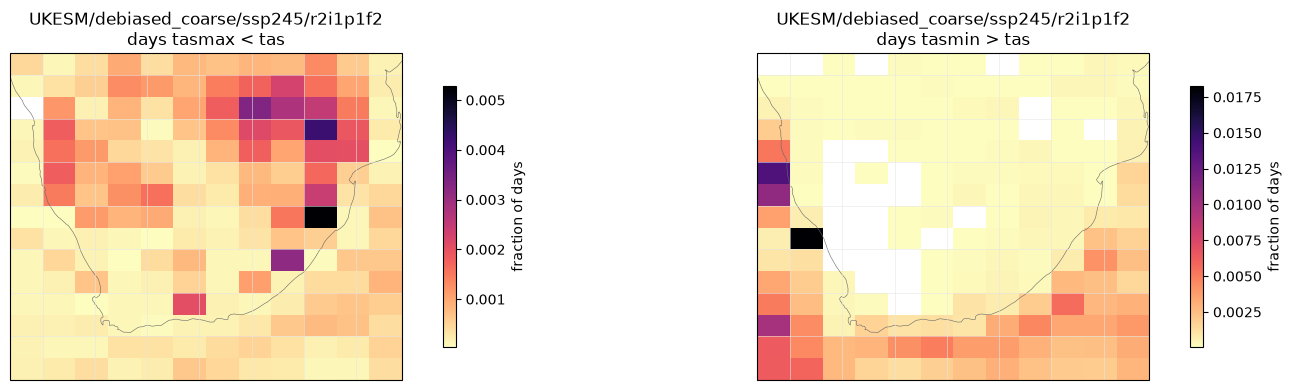

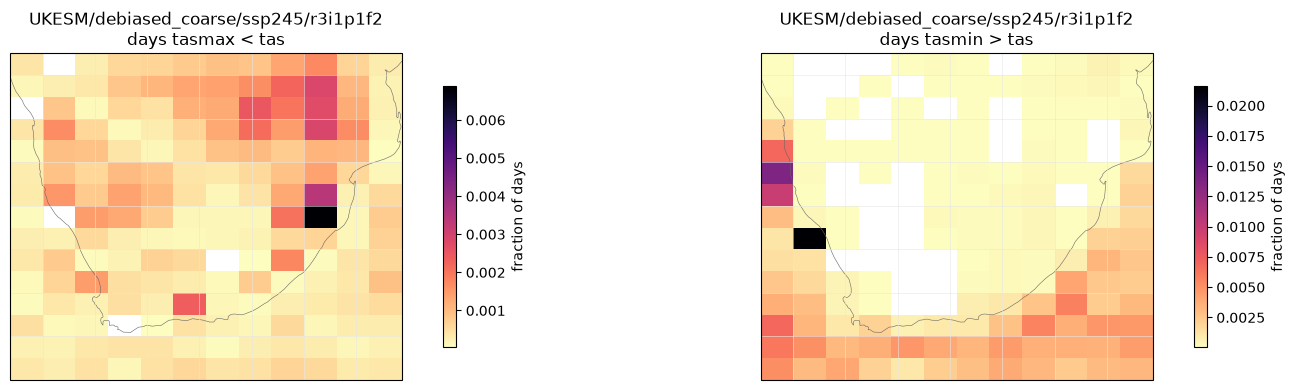

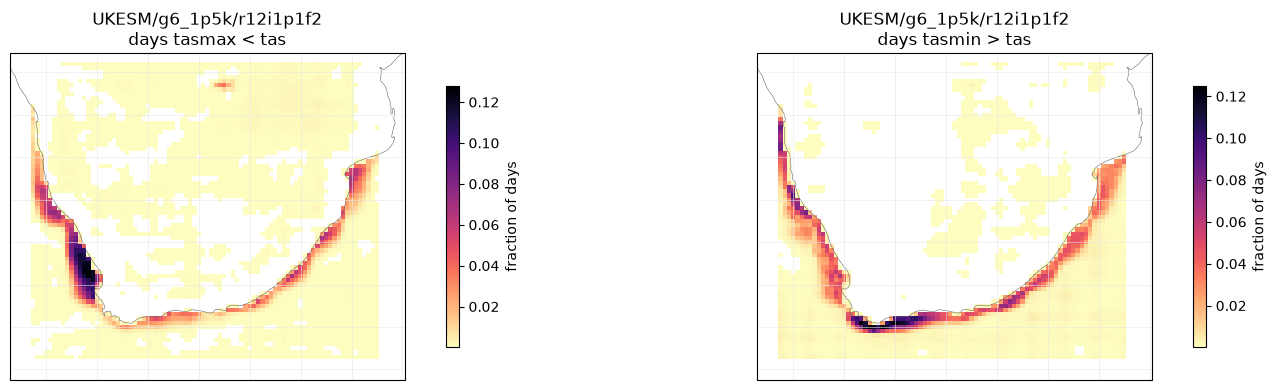

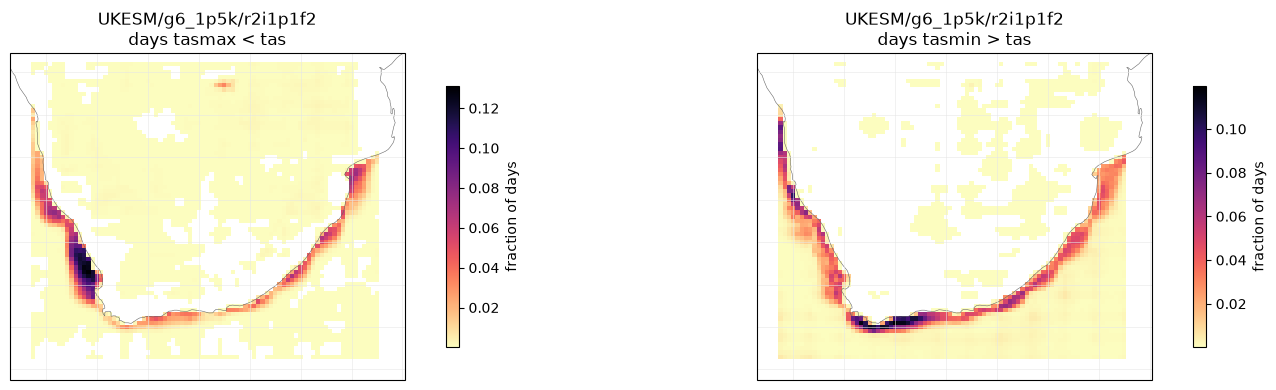

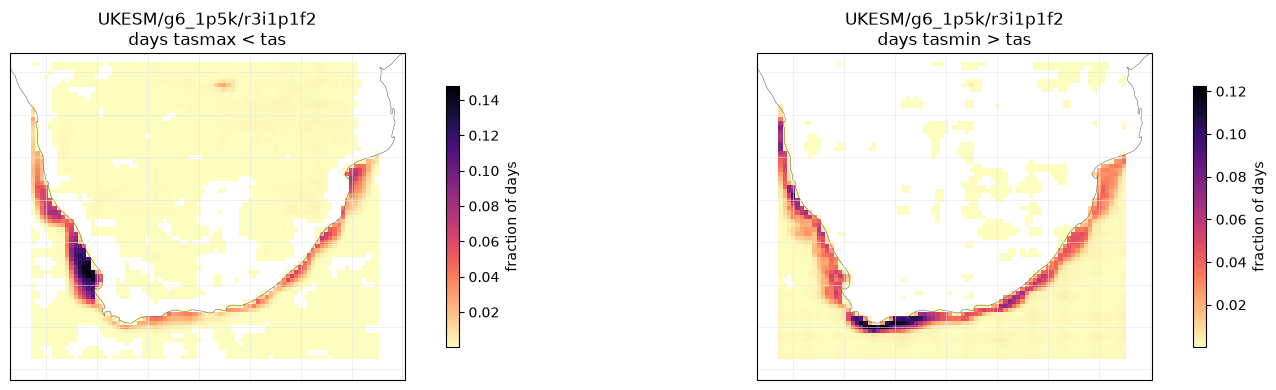

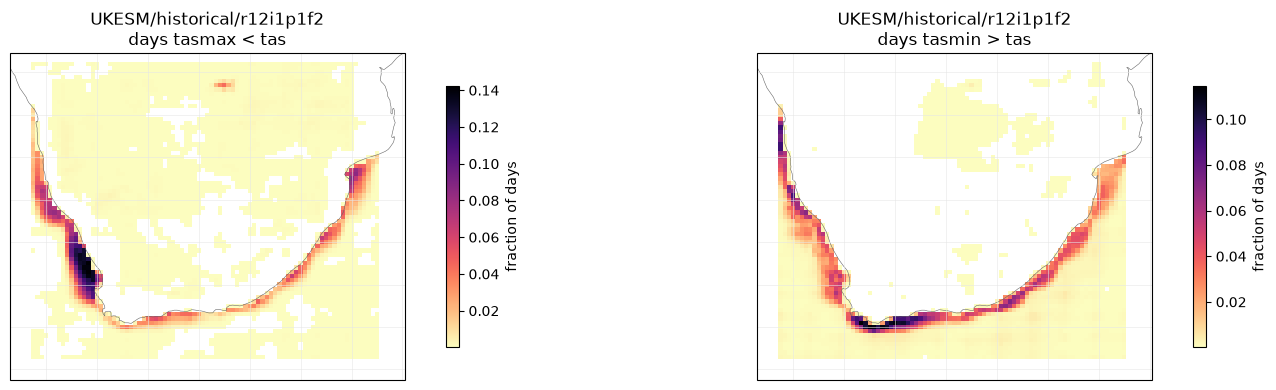

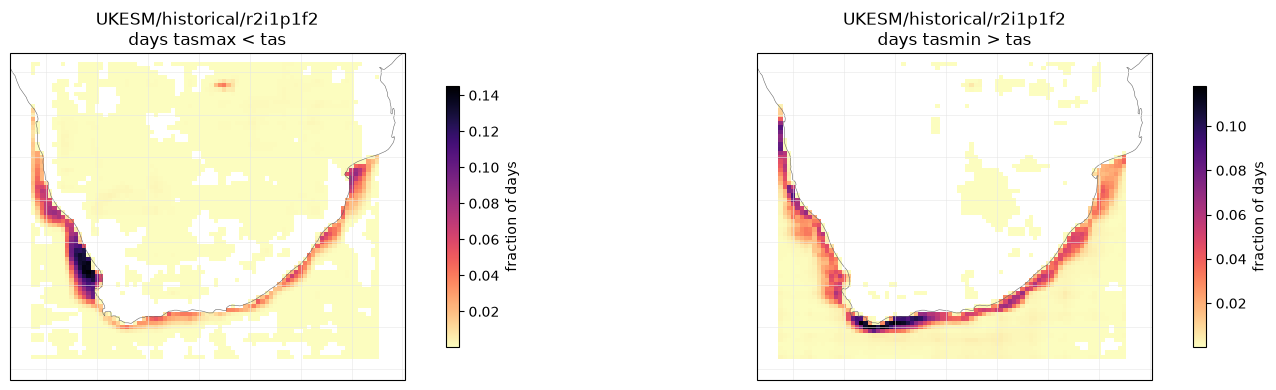

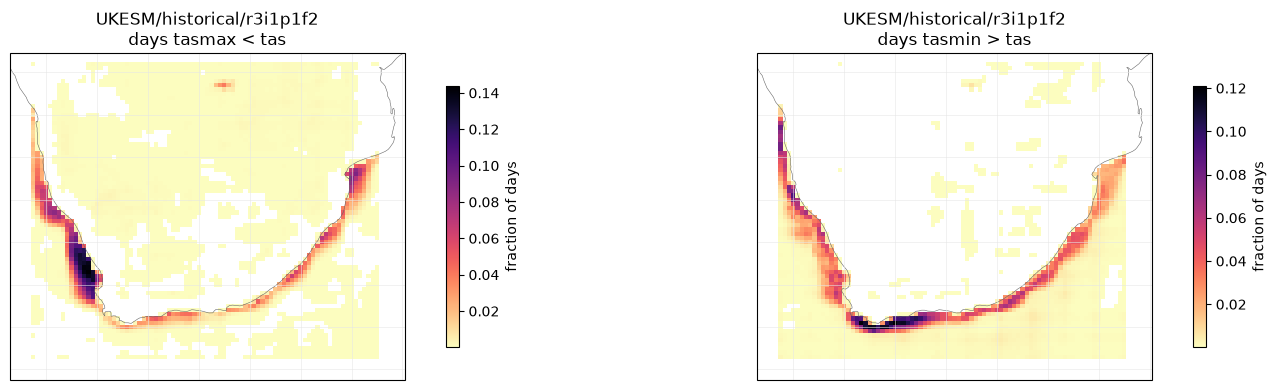

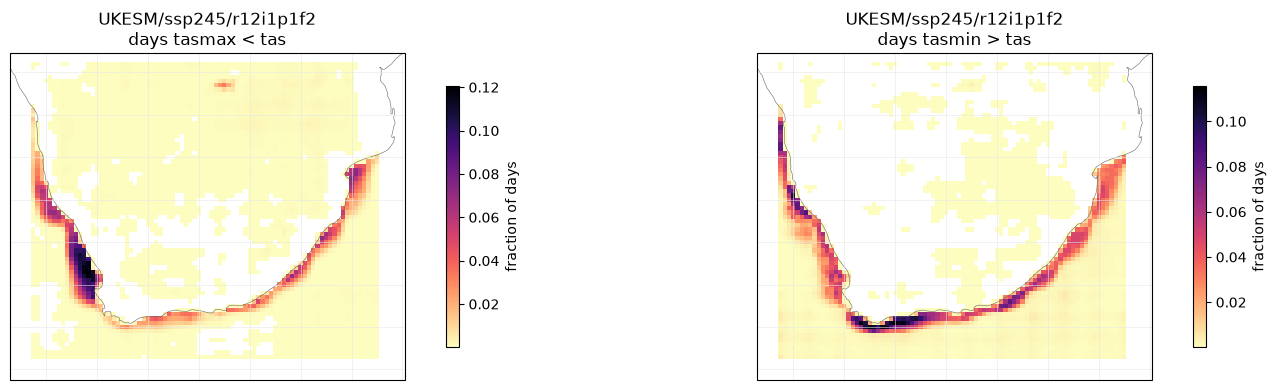

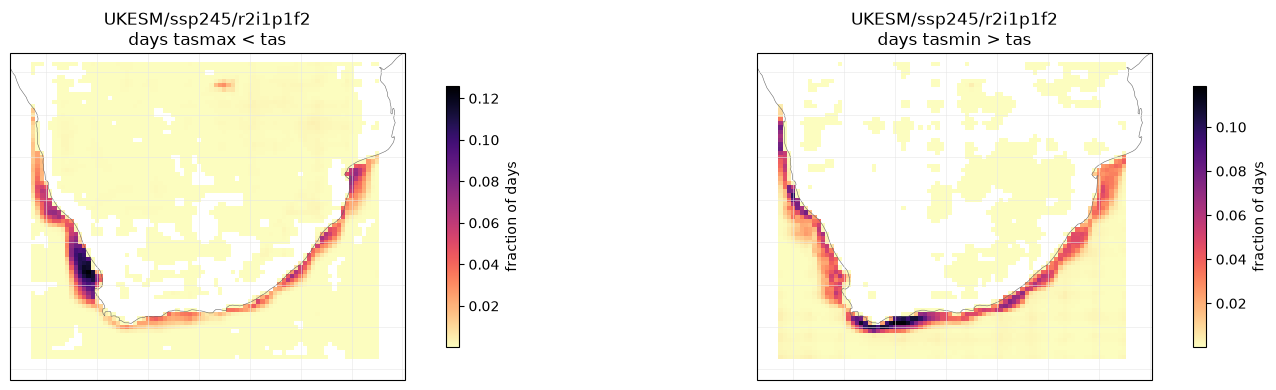

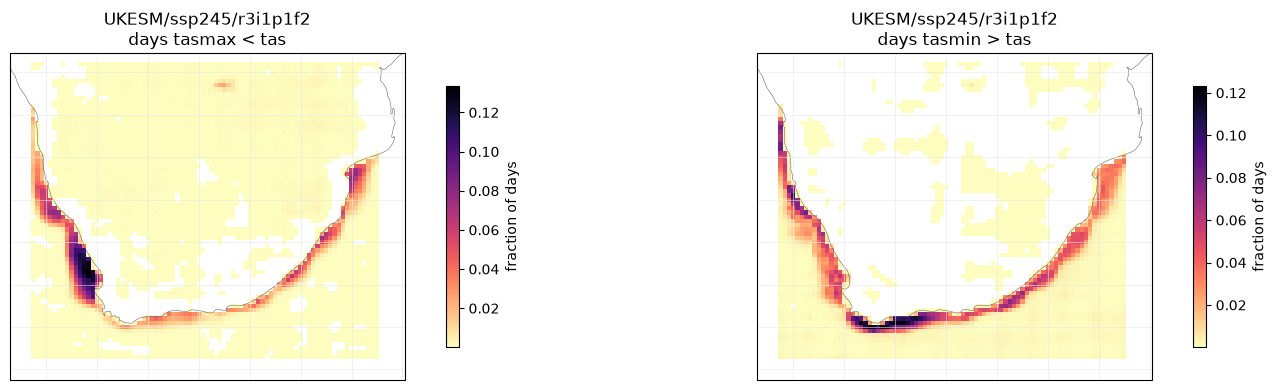

In [22]:
def plot_violation_maps(viol: dict) -> None:
    conds = [("max_lt_tas", "days tasmax < tas"), ("min_gt_tas", "days tasmin > tas")]
    for (gcm, group, m), ds in viol.items():
        n_time = ds.attrs["n_time"]
        fig, axes = plt.subplots(
            1, 2, figsize=(16, 4), subplot_kw={"projection": ccrs.PlateCarree()}
        )
        for ax, (cond, title) in zip(axes, conds):
            frac = (ds[cond] / n_time).where(ds[cond] > 0)
            frac.plot(
                ax=ax,
                transform=ccrs.PlateCarree(),
                cmap="magma_r",
                cbar_kwargs={"label": "fraction of days", "shrink": 0.8},
            )
            ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
            ax.gridlines(draw_labels=False, color="0.9", linewidth=0.4)
            ax.set_title(f"{gcm}/{group}/{m}\n{title}")
        plt.tight_layout()
        plt.show()


plot_violation_maps(viol)

### Land, ocean, and high latitudes

Same stratification as production, unchanged: for each `(gcm, group, member)` triplet we split the
two diagnostic conditions across five regions (global, land, ocean, land/ocean below 60° latitude,
poleward of 60°), area-weighted by cos(latitude), using a Natural Earth land mask on cell centres.
This regional box has no polar cells, so the `|lat|>=60` and `|lat|<60` rows are empty and identical
to their parents respectively -- a fact about the box, not a reason to change the check. The
land/ocean split is meaningful here, unlike on the earlier box: this one spans southern Africa and
open water on both sides.

In [23]:
# Land/ocean and high-latitude stratification of the Part-2 counts. This is pure post-processing of
# the per-cell day counts already in `viol`, so it triggers no further reads of the store. Unchanged
# from production -- see the markdown above for why results are expected to be sparse on this box.
_LAND_MASKS: dict[tuple[int, int], xr.DataArray] = {}


@functools.cache
def _land_polygons():
    """Union of the Natural Earth 50 m land polygons, cached for the session."""
    path = shpreader.natural_earth(resolution="50m", category="physical", name="land")
    return shapely.union_all(list(shpreader.Reader(path).geometries()))


def land_mask(template: xr.DataArray) -> xr.DataArray:
    """Boolean mask on template's grid, True where the cell centre falls on land.

    Unchanged from production: test cell centres against Natural Earth rather than the pipeline's
    optional ocean mask, which carries no Antarctica and rasterizes with all_touched=True. Cached per
    grid shape, since the coarse/fine families (and different GCM grids) differ.
    """
    key = (template.sizes["lat"], template.sizes["lon"])
    if key not in _LAND_MASKS:
        lon, lat = np.meshgrid(template["lon"].values, template["lat"].values)
        _LAND_MASKS[key] = xr.DataArray(
            shapely.contains_xy(_land_polygons(), lon, lat),
            coords={"lat": template["lat"], "lon": template["lon"]},
            dims=("lat", "lon"),
        )
    return _LAND_MASKS[key]


def regions_for(land: xr.DataArray) -> dict[str, xr.DataArray]:
    """Boolean region selectors on the land mask's grid, in reporting order."""
    abslat = np.abs(land["lat"])
    everywhere = xr.ones_like(land)
    return {
        "global": everywhere,
        "land": land,
        "ocean": ~land,
        "land |lat|<60": land & (abslat < 60),
        "ocean |lat|<60": ~land & (abslat < 60),
        "|lat|>=60": everywhere & (abslat >= 60),
    }


CONDS = {"max<tas": "max_lt_tas", "min>tas": "min_gt_tas"}


def regional_consistency_summary(viol: dict) -> pd.DataFrame:
    """Violation statistics per triplet and region, area-weighted by cos(lat). Unchanged from
    production -- see the markdown above for why regions are expected to be sparse here."""
    rows = {}
    for (gcm, group, member), ds in viol.items():
        counts = ds["max_lt_tas"]
        land = land_mask(counts)
        weights = np.cos(np.deg2rad(ds["lat"])).broadcast_like(counts)
        n_time = ds.attrs["n_time"]
        for name, sel in regions_for(land).items():
            w = weights.where(sel, 0.0)
            row = {"area_frac": round(float(w.sum() / weights.sum()), 4)}
            for label, cond in CONDS.items():
                ever = (ds[cond] > 0).astype("float32")
                freq = ds[cond] / n_time
                row[f"frac_area_ever_{label}"] = round(float(ever.weighted(w).mean(SPATIAL)), 5)
                row[f"mean_freq_{label}"] = round(float(freq.weighted(w).mean(SPATIAL)), 6)
            row["days_max<min"] = int(ds["max_lt_min"].where(sel, 0).sum())
            rows[(gcm, group, member, name)] = row
    # Build the MultiIndex explicitly (see `table`'s docstring).
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=["gcm", "group", "member", "region"])
    return df


regional_df = regional_consistency_summary(viol)
print(regional_df.to_string())

# The headline for the land-vs-ocean reading: how many times more often a unit of ocean area breaks
# the ordering than a unit of land area does. "land 0" means the ordering never broke over land.
print("\nocean:land ratio of mean violation frequency")
for gcm, group, member in viol:
    parts = []
    for label in CONDS:
        over_land = regional_df.loc[(gcm, group, member, "land"), f"mean_freq_{label}"]
        over_ocean = regional_df.loc[(gcm, group, member, "ocean"), f"mean_freq_{label}"]
        parts.append(f"{label}: {over_ocean / over_land:.1f}x" if over_land else f"{label}: land 0")
    print(f"  {gcm}/{group}/{member}  " + "   ".join(parts))

                                                                  area_frac  frac_area_ever_max<tas  mean_freq_max<tas  frac_area_ever_min>tas  mean_freq_min>tas  days_max<min
gcm         group                       member    region                                                                                                                       
CESM2-WACCM debiased_coarse/g6_1p5k     001       global             1.0000                 0.89270           0.004011                 0.92368           0.007168             0
                                                  land               0.6366                 0.83556           0.000507                 0.88013           0.000476             0
                                                  ocean              0.3634                 0.99281           0.010151                 1.00000           0.018893             0
                                                  land |lat|<60      0.6366                 0.83556           0.000507  

Interpretation depends on this run's actual table above -- production's specific ratios (7-8x
ocean:land for `tasmin > tas`, poleward concentration for `tasmax < tas`) came from a full-globe read
and won't transfer to this box. Read the `mean_freq_*` and `frac_area_ever_*` columns per
`gcm`/`group`/`member` directly.

What this box does show is the ocean half of production's pattern: `frac_area_ever_min>tas` reaches
1.00 over ocean in every triplet against 0.6-0.9 on land, and `mean_freq_min>tas` runs a couple of
orders of magnitude higher there. The violations track surface type rather than clustering on grid
artifacts, which is consistent with `tasmin` being bias-corrected from `dtr` and then downscaled --
the small diurnal range over water is where that path has least room. The direct test, per-cell
violation frequency against per-cell `dtr`, is not run here.

## Part 3: precipitation physical constraints (issue #459)

Same single-variable checks as production -- `pr` must never go negative, and no day may carry an
outlandishly large total -- counted per grid cell in the same Part-1 pass, per GCM. This section only
summarizes and maps the results.

In [24]:
def pr_physical_summary(phys: dict) -> pd.DataFrame:
    """One row per pr leaf: negative and outlandish-high day/cell tallies."""
    rows = {}
    for (gcm, group, _v, m), ds in phys.items():
        rows[(gcm, group, m)] = {
            "n_time": ds.attrs["n_time"],
            "neg_cell_days": int(ds.neg_days.sum()),
            "cells_with_neg": int((ds.neg_days > 0).sum()),
            "frac_cells_neg": round(float((ds.neg_days > 0).mean()), 5),
            "high_cell_days": int(ds.high_days.sum()),
            "cells_with_high": int((ds.high_days > 0).sum()),
        }
    # Build the MultiIndex explicitly (see `table`'s docstring).
    df = pd.DataFrame.from_dict(rows, orient="index")
    df.index = pd.MultiIndex.from_tuples(rows.keys(), names=["gcm", "group", "member"])
    return df


pr_physical_df = pr_physical_summary(pr_phys)
print(pr_physical_df.to_string())

n_neg = int(pr_physical_df["neg_cell_days"].sum())
n_high = int(pr_physical_df["high_cell_days"].sum())
print(f"\nNon-negativity holds everywhere (pr >= 0): {n_neg == 0} (negative cell-days: {n_neg})")
print(f"No outlandish daily totals: {n_high == 0} (outlandish cell-days: {n_high})")

                                                   n_time  neg_cell_days  cells_with_neg  frac_cells_neg  high_cell_days  cells_with_high
gcm         group                       member                                                                                           
CESM2-WACCM historical                  r1i1p1f1    13514              0               0             0.0               0                0
                                        r2i1p1f1    13514              0               0             0.0               0                0
                                        r3i1p1f1    13514              0               0             0.0               0                0
            ssp245                      001         31046              0               0             0.0               0                0
                                        010         19724              0               0             0.0               0                0
                                  

In [25]:
def plot_negativity_maps(phys: dict) -> None:
    """Map the fraction of days pr < 0, for any leaf that ever goes negative."""
    plotted = False
    for (gcm, group, _v, m), ds in phys.items():
        if int((ds.neg_days > 0).sum()) == 0:
            continue
        plotted = True
        frac = (ds.neg_days / ds.attrs["n_time"]).where(ds.neg_days > 0)
        fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()})
        frac.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap="magma_r",
            cbar_kwargs={"label": "fraction of days pr < 0", "shrink": 0.8},
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
        ax.gridlines(draw_labels=False, color="0.9", linewidth=0.4)
        ax.set_title(f"{gcm}/{group}/{m}\nnegative precipitation")
        plt.tight_layout()
        plt.show()
    if not plotted:
        print("No leaf has any negative precipitation — nothing to map.")


def pr_high_days(fp: xr.DataArray) -> list[tuple[str, float]]:
    """(date, kg m-2 s-1) for days whose spatial-max pr exceeds the outlandish threshold."""
    smax = fp.sel(stat="max")
    bad = (smax > PR_OUTLANDISH).values
    return [(str(t)[:10], float(x)) for t, x in zip(fp.time.values[bad], smax.values[bad])]


plot_negativity_maps(pr_phys)

# Report-only drill-down over the Part-1 fingerprints, restricted to pr leaves.
flagged = {k: pr_high_days(s.fingerprint) for k, s in stats.items() if k[2] == "pr"}
flagged = {k: days for k, days in flagged.items() if days}
if flagged:
    print("Outlandish precip days (report-only, spatial max > 2000 mm/day):")
    for (gcm, s, v, m), days in flagged.items():
        print(f"  {gcm}/{s}/{v}/{m}: {len(days)} days")
        for date, val in days:
            print(f"    {date}  {val:.3e} kg m-2 s-1 ({val * 86400:.0f} mm/day)")
else:
    print("No outlandish precip days flagged.")

No leaf has any negative precipitation — nothing to map.
No outlandish precip days flagged.


## Summary

Same three-part structure as production, run per GCM against the regional (wide) run instead of one
full-globe store:

- **Part 1** (issue #450): production's five checks, plus five that are specific to this notebook.
  Expect Check 1 to fail on every fine-grid leaf, and Checks 2/5 to flag any `pr` leaf with a
  domain-wide dry day, per the caveats above; Checks 1b, 3, 4 and 6-9 should pass cleanly.
  - **Check 1b** (interior NaNs) is the check that replaces Check 1 in the headline here: it masks
    the structural border shared by every leaf on a grid, so only a NaN that one leaf has and its
    neighbours don't counts as a failure.
  - **Check 6** (duplicate leaves) groups leaves by their per-day fingerprint bytes, catching a
    member or a variable written twice from the same source. Blind to cross-group duplication --
    see the caveat in that section.
  - **Check 7** (expected inventory) diffs the observed `(variable, member)` leaves against
    `EXPECTED`, hand-built from the run configs, and separately diffs each store's groups against
    the ones expected for that GCM -- only `CESM2-WACCM` carries `g6_1p5k_end`.
  - **Check 8** (time-axis regularity) requires a single 1-day step per leaf, catching gaps and
    duplicate timestamps inside the window that Check 4's first/last comparison cannot see.
  - **Check 9** (grid consistency) requires one grid per `(gcm, family)`, and the fine family to
    match the run's `subset_bounds`.
- **Part 2** (issue #448): `tasmin ≤ tas ≤ tasmax` ordering, per `(gcm, group, member)` triplet.
  `tasmax ≥ tasmin` should hold everywhere (#331); the other two relationships are diagnostic only.
  MIROC-ES2H and UKESM should surface historical triplets that CESM2-WACCM cannot (see the
  member-coverage note above). The land/ocean split is meaningful on this box, which spans both
  coasts; the `|lat|>=60` row stays empty.
- **Part 3** (issue #459): precipitation non-negativity and outlandish-total checks, per `pr` leaf.



In [26]:
cluster.shutdown()

2026-08-06 14:56:33,265 - distributed.deploy.adaptive - INFO - Adaptive scaling stopped: minimum=4 maximum=20. Reason: unknown
[2026-08-06 14:56:33,396][INFO    ][coiled] Cluster 1893078 deleted successfully.
